# GiBUU Propagation Model Training

This notebook trains the `GiBUUPropagationModel` for predicting particle feature changes during propagation.

**Workflow:**
1. Load processed NPZ data from `GiBUU_dataprep.ipynb`
2. Prepare data for training (call `prepare_propagation_data`)
3. Configure model and training parameters
4. Train model with PyTorch Lightning
5. Test trained model

**Model Architecture:**
- Zero-inflated architecture for E/p predictions (handles sparse changes)
- Predicts position deltas (Δx, Δy, Δz)
- Predicts E/p zero flag + values (ΔKE, ΔPx, ΔPy, ΔPz)
- Predicts step-level interaction flag

**Output:**
- Trained model saved in `lightning_logs/`
- Checkpoints for resuming training or inference


## Step 1: Imports


In [4]:
# Enable auto-reload of modules
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl
import numpy as np
import glob
from pathlib import Path
from typing import List, Tuple, Dict

# Import from gibuu_transformer package
from gibuu_transformer import (
    GiBUUPropagationModel,
    GiBUUPropagationLightning,
    gibuu_propagation_loss,
    prepare_propagation_data,
    load_pairs_from_npz,
    FEATS_MEAN,
    FEATS_SIGMA,
    FEATS_DELTA_MEAN,
    FEATS_DELTA_SIGMA,
    list_checkpoints,
    find_checkpoint
)

print(f"✓ Imports successful!")
print(f"  PyTorch version: {torch.__version__}")
print(f"  Lightning version: {pl.__version__}")
print(f"  Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"\nFeature normalization constants loaded:")
print(f"  FEATS_MEAN: {FEATS_MEAN}")
print(f"  FEATS_SIGMA: {FEATS_SIGMA}")
print(f"  FEATS_DELTA_MEAN: {FEATS_DELTA_MEAN}")
print(f"  FEATS_DELTA_SIGMA: {FEATS_DELTA_SIGMA}")

NPZ_PATH = "/exp/dune/data/users/yinrui/GiBUU/GPTdata/processed_data"  # Path to NPZ files

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Imports successful!
  PyTorch version: 2.8.0+cu128
  Lightning version: 2.5.2
  Device: cuda

Feature normalization constants loaded:
  FEATS_MEAN: [0.0, 0.0, 6.13, 0.42, 0.0, 0.0, 0.5]
  FEATS_SIGMA: [5.89, 5.89, 9.33, 0.975, 0.304, 0.304, 1.123]
  FEATS_DELTA_MEAN: [0.0, 0.0, 0.05, 0.0, 0.0, 0.0, 0.0]
  FEATS_DELTA_SIGMA: [0.165, 0.165, 0.184, 6.72e-05, 0.0125, 0.0125, 0.0125]


## Step 2: Load NPZ Data

Load preprocessed data from `GiBUU_dataprep.ipynb` output.


In [19]:
# Configuration
JOB_ID = 990  # Job ID to load
MAX_PAIRS = None  # Set to a number for quick testing, None to load all

# Load both types of pairs for job 990
with_file = Path(NPZ_PATH) / "npz_with_changes" / f"pairs_with_changes_{JOB_ID:06d}.npz"
without_file = Path(NPZ_PATH) / "npz_without_changes" / f"pairs_without_changes_{JOB_ID:06d}.npz"

with_changes_files = [str(with_file)] if with_file.exists() else []
without_changes_files = [str(without_file)] if without_file.exists() else []

print(f"Loading Job {JOB_ID:06d}...")
print(f"  Interaction file: {with_file.name} {'✓' if with_file.exists() else '✗'}")
print(f"  Propagation file: {without_file.name} {'✓' if without_file.exists() else '✗'}")

# Load pairs
print(f"\nData loaded:")
pairs_with_changes = load_pairs_from_npz(with_changes_files, max_pairs=MAX_PAIRS, random_subset=True)
print(f"  Interaction pairs: {len(pairs_with_changes)}")
pairs_without_changes = load_pairs_from_npz(without_changes_files, max_pairs=MAX_PAIRS, random_subset=True)
print(f"  Propagation pairs: {len(pairs_without_changes)}")
print(f"  Total: {len(pairs_with_changes) + len(pairs_without_changes)}")
if MAX_PAIRS is not None:
    print(f"  (Limited to {MAX_PAIRS} pairs per file for quick testing)")


Loading Job 000990...
  Interaction file: pairs_with_changes_000990.npz ✓
  Propagation file: pairs_without_changes_000990.npz ✓

Data loaded:
  Interaction pairs: 147408
  Propagation pairs: 3548192
  Total: 3695600


## Step 3: Prepare Data for Training

Convert pairs to format expected by the propagation model.


In [20]:
# Prepare propagation data
propagation_data = prepare_propagation_data(
    pairs_without_changes=pairs_without_changes,
    pairs_with_changes=pairs_with_changes,
    stats_path=None  # Uses constants from constants.py
)

print("✓ Data prepared for training:")
print(f"  Total steps: {len(propagation_data['particle_types'])}")
print(f"  Non-interaction steps: {sum(1 for x in propagation_data['target_interaction'] if x == 0)}")
print(f"  Interaction steps: {sum(propagation_data['target_interaction'])}")

# Show example
idx = 0
print(f"\nExample step {idx}:")
print(f"  Particle types: {propagation_data['particle_types'][idx][:5]}... ({len(propagation_data['particle_types'][idx])} particles)")
print(f"  Input features shape: {propagation_data['input_features'][idx].shape}")
print(f"  Target features shape: {propagation_data['target_features'][idx].shape}")
print(f"  Interaction flag: {propagation_data['target_interaction'][idx]}")


Preparing propagation data...
  Non-interaction pairs: 3548192
  Interaction pairs: 147408
✓ Prepared 3695600 steps
  Non-interaction: 3548192
  Interaction: 147408
✓ Data prepared for training:
  Total steps: 3695600
  Non-interaction steps: 3548192
  Interaction steps: 147408

Example step 0:
  Particle types: [1007, 1153, 1262, 1153, 1253]... (5 particles)
  Input features shape: (5, 7)
  Target features shape: (5, 7)
  Interaction flag: 0


## Step 4: Create Dataset and DataLoader


In [6]:
class ParticlePropagationDataset(Dataset):
    """
    Dataset for particle propagation model.
    """
    def __init__(self, particle_types, input_features, target_features, target_interaction, has_target_features):
        self.particle_types = particle_types
        self.input_features = input_features
        self.target_features = target_features
        self.target_interaction = target_interaction
        self.has_target_features = has_target_features
    
    def __len__(self):
        return len(self.particle_types)
    
    def __getitem__(self, idx):
        return {
            'particle_types': self.particle_types[idx],
            'input_features': self.input_features[idx],
            'target_features': self.target_features[idx],
            'target_interaction': self.target_interaction[idx],
            'has_target_features': self.has_target_features[idx]
        }

def collate_propagation_data(batch):
    """
    Collate function with padding for variable-length sequences.
    """
    # Find max length in this batch
    max_len = max(len(item['particle_types']) for item in batch)
    
    batch_size = len(batch)
    feature_dim = batch[0]['input_features'].shape[-1]
    
    # Initialize tensors
    particle_types = torch.zeros(batch_size, max_len, dtype=torch.long)
    input_features = torch.zeros(batch_size, max_len, feature_dim, dtype=torch.float32)
    target_features = torch.zeros(batch_size, max_len, feature_dim, dtype=torch.float32)
    target_interaction = torch.zeros(batch_size, dtype=torch.long)
    has_target_features = torch.zeros(batch_size, max_len, dtype=torch.bool)
    padding_mask = torch.ones(batch_size, max_len, dtype=torch.bool)  # True for padding
    
    # Fill tensors
    for i, item in enumerate(batch):
        seq_len = len(item['particle_types'])
        particle_types[i, :seq_len] = torch.tensor(item['particle_types'], dtype=torch.long)
        input_features[i, :seq_len] = torch.tensor(item['input_features'], dtype=torch.float32)
        
        # Handle None target_features (for interaction pairs)
        if item['target_features'] is not None:
            target_features[i, :seq_len] = torch.tensor(item['target_features'], dtype=torch.float32)
        
        target_interaction[i] = item['target_interaction']
        
        # has_target_features is a boolean for the whole sequence
        has_target_features[i, :seq_len] = item['has_target_features']
        
        padding_mask[i, :seq_len] = False  # False for valid positions
    
    return {
        'particle_types': particle_types,
        'input_features': input_features,
        'target_features': target_features,
        'target_interaction': target_interaction,
        'has_target_features': has_target_features,
        'padding_mask': padding_mask
    }

# Create dataset
dataset = ParticlePropagationDataset(
    particle_types=propagation_data['particle_types'],
    input_features=propagation_data['input_features'],
    target_features=propagation_data['target_features'],
    target_interaction=propagation_data['target_interaction'],
    has_target_features=propagation_data['has_target_features']
)

# Split into train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"✓ Datasets created:")
print(f"  Train: {len(train_dataset)} steps")
print(f"  Val: {len(val_dataset)} steps")


NameError: name 'propagation_data' is not defined

## Step 5: Configure and Train Model


In [8]:
# Configuration
cfg = {
    'model': {
        'num_particle_types': 4096,
        'feature_dim': 7,
        'hidden_dims': [256, 128, 64],
        'dropout': 0.1,
        'aggregation_method': 'mean',
        'use_zero_inflation': True  # Set to False for simpler direct prediction
    },
    # Loss weights
    'feature_loss_weight': 1.0,
    'position_loss_weight': 1.0,
    'em_zero_loss_weight': 1.0,
    'em_value_loss_weight': 1.0,
    'interaction_loss_weight': 1.0,
    'apply_feature_loss_only_when_no_interaction': True,
    'pos_weight': 10.0,  # Weight for positive class (interactions are rare)
    'use_huber_loss': True,
    'huber_delta': 1.0,
    # Training config
    'lr': 1e-4,
    'weight_decay': 1e-5
}

# Training hyperparameters
BATCH_SIZE = 32
MAX_EPOCHS = 50
LOG_EVERY_N_STEPS = 100
EXPERIMENT_NAME = "gibuu_propagation"

# Resume training configuration
RESUME_TRAINING = True  # Set to True to resume from checkpoint
CHECKPOINT_PATH = None   # Optional: specify exact checkpoint path
CHECKPOINT_NAME = "last.ckpt"  # Name of checkpoint to look for (default: "last.ckpt")

print("✓ Configuration set:")
print(f"  Model: GiBUUPropagationModel (zero_inflation={cfg['model']['use_zero_inflation']})")
print(f"  Hidden dims: {cfg['model']['hidden_dims']}")
print(f"  Learning rate: {cfg['lr']}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {MAX_EPOCHS}")
print(f"  Resume training: {RESUME_TRAINING}")


✓ Configuration set:
  Model: GiBUUPropagationModel (zero_inflation=True)
  Hidden dims: [256, 128, 64]
  Learning rate: 0.0001
  Batch size: 32
  Max epochs: 50
  Resume training: True


In [23]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_propagation_data,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_propagation_data,
    num_workers=4,
    pin_memory=True
)

print(f"✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


✓ DataLoaders created:
  Train batches: 92390
  Val batches: 23098


In [24]:
# Create model (with resume support)
if RESUME_TRAINING:
    # Find checkpoint to resume from
    CHECKPOINT_PATH = find_checkpoint(
        experiment_name=EXPERIMENT_NAME,
        checkpoint_path=CHECKPOINT_PATH,
        checkpoint_name=CHECKPOINT_NAME
    )
    
    if CHECKPOINT_PATH is not None:
        model = GiBUUPropagationLightning.load_from_checkpoint(CHECKPOINT_PATH, cfg=cfg)
    else:
        print("⚠ No checkpoint found, starting new training")
        RESUME_TRAINING = False
        model = GiBUUPropagationLightning(cfg)
else:
    print("✓ Starting new training")
    model = GiBUUPropagationLightning(cfg)

# Create trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices='auto',
    log_every_n_steps=LOG_EVERY_N_STEPS,
    
    # Checkpointing
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=f'lightning_logs/{EXPERIMENT_NAME}/checkpoints',
            filename='model-{epoch:02d}-{val_loss:.4f}',
            monitor='val_loss',
            mode='min',
            save_top_k=3,
            save_last=True
        ),
        pl.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            mode='min',
            verbose=True
        )
    ],
    
    # Logging
    logger=pl.loggers.CSVLogger(
        save_dir='lightning_logs',
        name=EXPERIMENT_NAME
    )
)

print("✓ Trainer created")
print(f"  Logs will be saved to: lightning_logs/{EXPERIMENT_NAME}/")
print(f"  Checkpoints will be saved to: lightning_logs/{EXPERIMENT_NAME}/checkpoints/")


✓ Found checkpoint: lightning_logs/gibuu_propagation/checkpoints/last.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


✓ Trainer created
  Logs will be saved to: lightning_logs/gibuu_propagation/
  Checkpoints will be saved to: lightning_logs/gibuu_propagation/checkpoints/


In [11]:
# Train!
if RESUME_TRAINING:
    print(f"Resuming training from checkpoint...\n")
    trainer.fit(model, train_loader, val_loader, ckpt_path=CHECKPOINT_PATH)
else:
    print("Starting training from scratch...\n")
    trainer.fit(model, train_loader, val_loader)

print("\n✓ Training complete!")
print(f"  Best model checkpoint: {trainer.checkpoint_callback.best_model_path}")
print(f"  Last checkpoint: {trainer.checkpoint_callback.last_model_path}")


Restoring states from the checkpoint path at lightning_logs/gibuu_propagation/checkpoints/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type                  | Params | Mode 
-------------------------------------------------------
0 | net  | GiBUUPropagationModel | 181 K  | train
-------------------------------------------------------
181 K     Trainable params
0         Non-trainable params
181 K     Total params
0.727     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at lightning_logs/gibuu_propagation/checkpoints/last.ckpt


Resuming training from checkpoint...



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Exception ignored in: <function _releaseLock at 0x7f3a1da1b010>
Traceback (most recent call last):
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/logging/__init__.py", line 228, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 

KeyboardInterrupt

Traceback (most recent call last):
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/hom

Loading metrics from: lightning_logs/gibuu_propagation/combined.csv
Columns: ['epoch', 'step', 'train_em_value_loss', 'train_em_zero_loss', 'train_feature_loss', 'train_interaction_loss', 'train_loss', 'train_position_loss', 'val_em_value_loss', 'val_em_zero_loss', 'val_feature_loss', 'val_interaction_loss', 'val_loss', 'val_position_loss']
✓ Loss curves plotted for propagation model

FINAL LOSS VALUES (Epoch 31):
  val_interaction_loss          : 0.515647
  val_position_loss             : 0.017804
  val_em_zero_loss              : 0.006444
  val_em_value_loss             : 0.056682
  val_feature_loss              : 0.080930


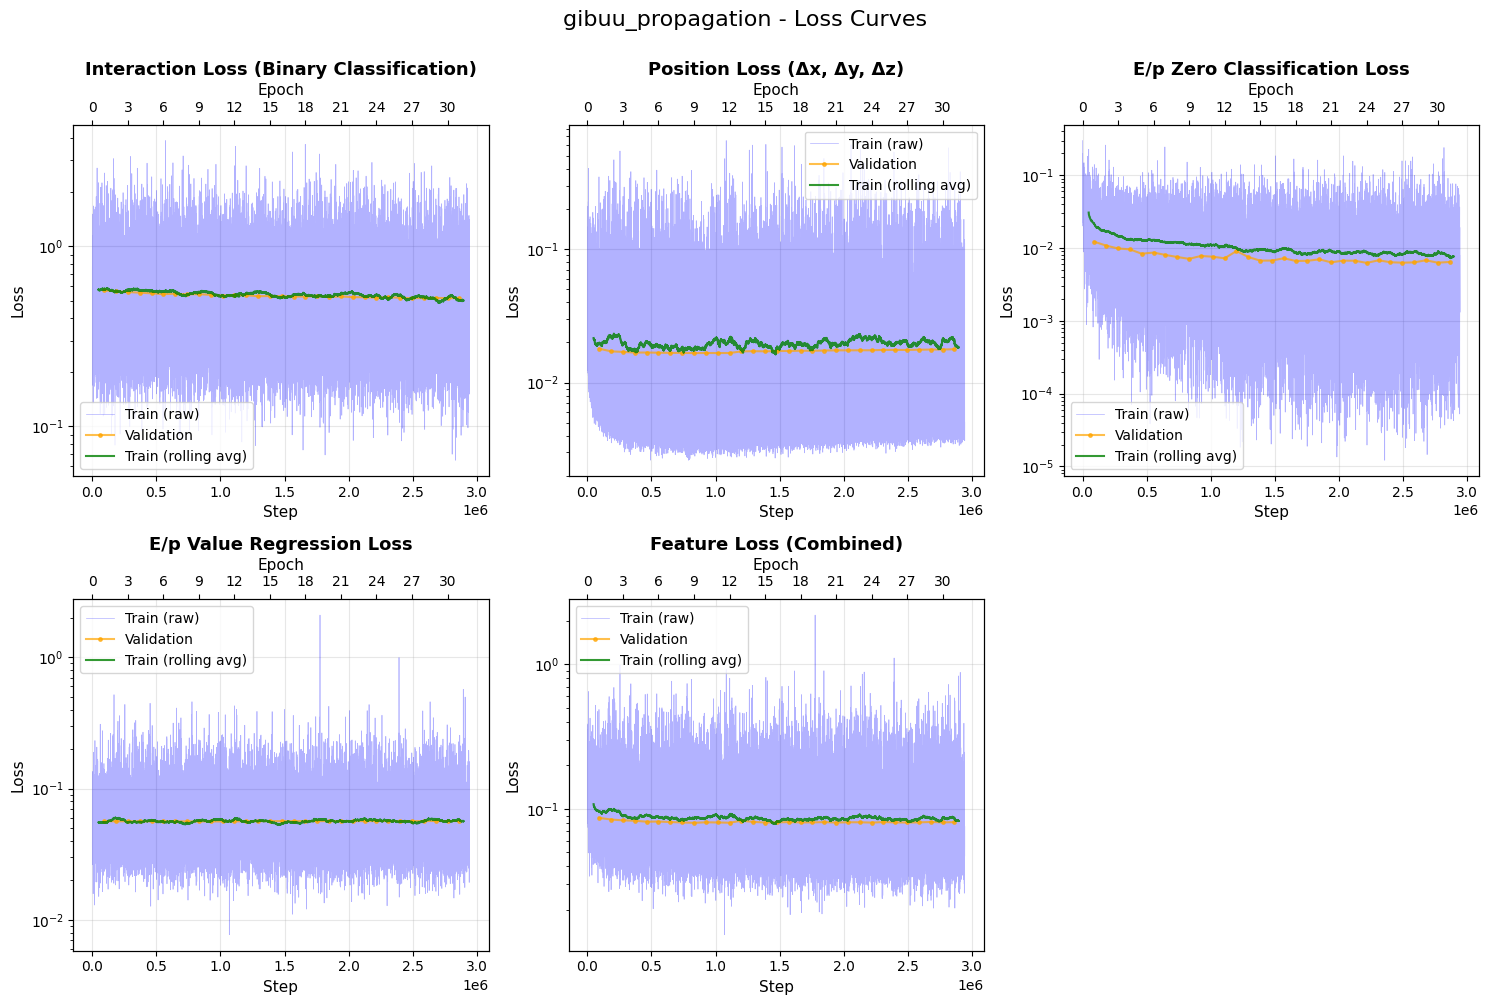

In [15]:
### Plot Loss Curves
from gibuu_transformer import plot_loss_curves
import matplotlib.pyplot as plt
import pandas as pd

EXPERIMENT_NAME = "gibuu_propagation"
COMBINE_CSV = True
if COMBINE_CSV:
    csv_idx_list = [1, 2] # modify the list
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"
    dfs = [pd.read_csv(f'lightning_logs/{EXPERIMENT_NAME}/version_{i}/metrics.csv') for i in csv_idx_list]
    combined = pd.concat(dfs, ignore_index=True)
    combined.to_csv(csv_path, index=False)
else:
    csv_idx = 0 # modify the index
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/version_{csv_idx}/metrics.csv"

# Option 2: Plot from combined CSV (if you've combined multiple versions)
# csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"

fig, axes = plot_loss_curves(
    csv_path=csv_path,
    mode='propagation',
    figsize=(15, 10),
    title=f'{EXPERIMENT_NAME} - Loss Curves',
    logy=True,
    custom_epoch_ticks = 10
)

if fig is not None:
    plt.show()

---

## Test

Load trained model and test predictions.


In [45]:
### Load Best Checkpoint

#checkpoint_path = trainer.checkpoint_callback.best_model_path
checkpoint_path = "lightning_logs/gibuu_propagation/checkpoints/last.ckpt"

model_loaded = GiBUUPropagationLightning.load_from_checkpoint(checkpoint_path)
model_loaded.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_loaded.to(device)

print(f"✓ Model loaded from: {checkpoint_path}")

✓ Model loaded from: lightning_logs/gibuu_propagation/checkpoints/last.ckpt


In [74]:
### Load Test Sample

# Configuration for test sample
TEST_SAMPLE_SIZE_prop = 10000  # Number of pairs without changes (propagation) to load for testing

# Calculate TEST_SAMPLE_SIZE_int based on ratio from training data
# Use the ratio: test_sample_size_with_int / test_sample_size_without_int
if 'pairs_with_changes' in globals() and 'pairs_without_changes' in globals():
    test_sample_size_with_int = len(pairs_with_changes)
    test_sample_size_without_int = len(pairs_without_changes)
    if test_sample_size_without_int > 0:
        TEST_SAMPLE_SIZE_int = int(TEST_SAMPLE_SIZE_prop * test_sample_size_with_int / test_sample_size_without_int)
    else:
        TEST_SAMPLE_SIZE_int = TEST_SAMPLE_SIZE_prop  # Fallback
else:
    # Fallback if training data variables not available
    TEST_SAMPLE_SIZE_int = TEST_SAMPLE_SIZE_prop
    print("Warning: Training data variables not available, using TEST_SAMPLE_SIZE_int = TEST_SAMPLE_SIZE_prop")
TEST_SAMPLE_SIZE_int = 400

print(f"Test sample sizes:")
print(f"  TEST_SAMPLE_SIZE_prop (without changes): {TEST_SAMPLE_SIZE_prop}")
print(f"  TEST_SAMPLE_SIZE_int (with changes): {TEST_SAMPLE_SIZE_int}")

# Option 1: Use a subset of the training sample (COMMENTED OUT)
# import random
# random.seed(42)
# test_indices = random.sample(range(len(train_dataset)), min(TEST_SAMPLE_SIZE_prop, len(train_dataset)))
# test_subset = torch.utils.data.Subset(train_dataset, test_indices)
# test_loader = DataLoader(
#     test_subset,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     collate_fn=collate_propagation_data,
#     num_workers=0,  # Set to 0 for testing
#     pin_memory=False
# )
# print(f"✓ Test sample loaded from training data: {len(test_subset)} steps")

# Option 2: Load test sample from NPZ file with TEST_JOB_ID
TEST_JOB_ID = 1000
test_file_with = Path(NPZ_PATH) / "npz_with_changes" / f"pairs_with_changes_{TEST_JOB_ID:06d}.npz"
test_file_without = Path(NPZ_PATH) / "npz_without_changes" / f"pairs_without_changes_{TEST_JOB_ID:06d}.npz"
test_files_with = [str(test_file_with)] if test_file_with.exists() else []
test_files_without = [str(test_file_without)] if test_file_without.exists() else []

if not test_files_with and not test_files_without:
    print(f"⚠ Test files not found:")
    print(f"  {test_file_with.name} {'✓' if test_file_with.exists() else '✗'}")
    print(f"  {test_file_without.name} {'✓' if test_file_without.exists() else '✗'}")
    print("  Falling back to validation loader...")
    test_loader = val_loader
else:
    print(f"\nLoading test sample from Job {TEST_JOB_ID:06d}...")
    print(f"  With changes file: {test_file_with.name} {'✓' if test_file_with.exists() else '✗'}")
    print(f"  Without changes file: {test_file_without.name} {'✓' if test_file_without.exists() else '✗'}")
    
    # Load test pairs with separate sizes
    test_pairs_with = load_pairs_from_npz(test_files_with, max_pairs=TEST_SAMPLE_SIZE_int, random_subset=True) if test_files_with else []
    test_pairs_without = load_pairs_from_npz(test_files_without, max_pairs=TEST_SAMPLE_SIZE_prop, random_subset=True) if test_files_without else []
    
    if len(test_pairs_with) == 0 and len(test_pairs_without) == 0:
        print("⚠ No test pairs loaded, falling back to validation loader...")
        test_loader = val_loader
    else:
        print(f"✓ Test pairs loaded: {len(test_pairs_with)} with changes, {len(test_pairs_without)} without changes")
        
        # Prepare test data
        test_data = prepare_propagation_data(
            pairs_without_changes=test_pairs_without,
            pairs_with_changes=test_pairs_with,
            stats_path=None  # Uses constants from constants.py
        )
        
        # Create test dataset and loader
        test_dataset = ParticlePropagationDataset(
            particle_types=test_data['particle_types'],
            input_features=test_data['input_features'],
            target_features=test_data['target_features'],
            target_interaction=test_data['target_interaction'],
            has_target_features=test_data['has_target_features']
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            collate_fn=collate_propagation_data,
            num_workers=0,  # Set to 0 for testing
            pin_memory=False
        )
        
        print(f"✓ Test dataset created: {len(test_dataset)} steps")
        print(f"  Test batches: {len(test_loader)}")


Test sample sizes:
  TEST_SAMPLE_SIZE_prop (without changes): 10000
  TEST_SAMPLE_SIZE_int (with changes): 400

Loading test sample from Job 001000...
  With changes file: pairs_with_changes_001000.npz ✓
  Without changes file: pairs_without_changes_001000.npz ✓
✓ Test pairs loaded: 400 with changes, 10000 without changes
Preparing propagation data...
  Non-interaction pairs: 10000
  Interaction pairs: 400
✓ Prepared 10400 steps
  Non-interaction: 10000
  Interaction: 400
✓ Test dataset created: 10400 steps
  Test batches: 325


In [75]:
### Example Events from Test Sample

from gibuu_transformer.data_processing import decode_id
from gibuu_transformer.constants import (
    FEATS_MEAN, FEATS_SIGMA, FEATS_DELTA_MEAN, FEATS_DELTA_SIGMA,
    PAD_TOKEN, EOS_STEP_TOKEN, START_TOKEN
)

# Get a batch from test loader
model_loaded.eval()
example_batch = next(iter(test_loader))
example_batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in example_batch.items()}

# Make predictions
with torch.no_grad():
    output = model_loaded(
        example_batch['particle_types'],
        example_batch['input_features'],
        example_batch['padding_mask']
    )

# Helper function to decode particle ID to readable format
def format_particle_id(encoded_id):
    """Format encoded particle ID to readable string."""
    if encoded_id == PAD_TOKEN:
        return "PAD"
    elif encoded_id == EOS_STEP_TOKEN:
        return "EOS"
    elif encoded_id == START_TOKEN:
        return "START"
    else:
        try:
            gibuu_id, charge, is_real = decode_id(int(encoded_id))
            charge_str = f"+{charge}" if charge > 0 else str(charge) if charge < 0 else "0"
            return f"ID={gibuu_id},Q={charge_str}"
        except:
            return f"Unknown({encoded_id})"

# Helper function to format features
def format_features(feats_norm, feats_mean, feats_sigma):
    """Denormalize and format features."""
    feats_denorm = feats_norm * feats_sigma + feats_mean
    return {
        'x': feats_denorm[0].item(),
        'y': feats_denorm[1].item(),
        'z': feats_denorm[2].item(),
        'KE': feats_denorm[3].item(),
        'Px': feats_denorm[4].item(),
        'Py': feats_denorm[5].item(),
        'Pz': feats_denorm[6].item()
    }

# Helper function to format deltas
def format_deltas(deltas_norm, delta_mean, delta_sigma):
    """Denormalize and format deltas."""
    deltas_denorm = deltas_norm * delta_sigma + delta_mean
    return {
        'Δx': deltas_denorm[0].item(),
        'Δy': deltas_denorm[1].item(),
        'Δz': deltas_denorm[2].item(),
        'ΔKE': deltas_denorm[3].item(),
        'ΔPx': deltas_denorm[4].item(),
        'ΔPy': deltas_denorm[5].item(),
        'ΔPz': deltas_denorm[6].item()
    }

# Prepare normalization tensors
feats_mean = torch.tensor(FEATS_MEAN, dtype=torch.float32)
feats_sigma = torch.tensor(FEATS_SIGMA, dtype=torch.float32)
delta_mean = torch.tensor(FEATS_DELTA_MEAN, dtype=torch.float32)
delta_sigma = torch.tensor(FEATS_DELTA_SIGMA, dtype=torch.float32)

# Move normalization tensors to device (for computations)
delta_mean = delta_mean.to(device)
delta_sigma = delta_sigma.to(device)
feats_mean = feats_mean.to(device)
feats_sigma = feats_sigma.to(device)

# Create CPU versions for formatting functions (since features are moved to CPU for display)
feats_mean_cpu = torch.tensor(FEATS_MEAN, dtype=torch.float32)
feats_sigma_cpu = torch.tensor(FEATS_SIGMA, dtype=torch.float32)
delta_mean_cpu = torch.tensor(FEATS_DELTA_MEAN, dtype=torch.float32)
delta_sigma_cpu = torch.tensor(FEATS_DELTA_SIGMA, dtype=torch.float32)

# Get model outputs
predicted_deltas = output['predicted_deltas']  # (batch, N, 7) - normalized
predicted_interaction = torch.sigmoid(output['interaction_prediction'])  # (batch,) - probability

# Get input and target data
input_types = example_batch['particle_types']  # (batch, N)
input_features = example_batch['input_features']  # (batch, N, 7) - normalized
target_features = example_batch['target_features']  # (batch, N, 7) or None - normalized
target_interaction = example_batch['target_interaction']  # (batch,) - binary
padding_mask = example_batch['padding_mask']  # (batch, N) - True for padded
has_target_features = example_batch.get('has_target_features', None)  # (batch,) or None

# Denormalize predicted deltas
predicted_deltas_denorm = predicted_deltas * delta_sigma.unsqueeze(0).unsqueeze(0) + delta_mean.unsqueeze(0).unsqueeze(0)

# Compute predicted features: input_features + predicted_deltas
# First denormalize input features
input_features_denorm = input_features * feats_sigma.unsqueeze(0).unsqueeze(0) + feats_mean.unsqueeze(0).unsqueeze(0)
# Add deltas
predicted_features_denorm = input_features_denorm + predicted_deltas_denorm

# Denormalize target features if available
if target_features is not None:
    target_features_denorm = target_features * feats_sigma.unsqueeze(0).unsqueeze(0) + feats_mean.unsqueeze(0).unsqueeze(0)
else:
    target_features_denorm = None

# Select 5 examples (or fewer if batch is smaller)
num_examples = min(3, predicted_deltas.size(0))

sep_line = '=' * 100
print(f"{sep_line}")
print(f"EXAMPLE PREDICTIONS (showing {num_examples} examples from test sample)")
print(f"{sep_line}")

for iex in range(num_examples):
    print(f"\n{sep_line}")
    print(f"EXAMPLE {iex + 1}")
    print(f"{sep_line}")
    
    # Get valid particles (excluding padding)
    valid_mask = ~padding_mask[iex]
    input_types_valid = input_types[iex][valid_mask].cpu().numpy()
    input_feats_valid = input_features_denorm[iex][valid_mask].cpu()
    predicted_deltas_valid = predicted_deltas_denorm[iex][valid_mask].cpu()
    predicted_feats_valid = predicted_features_denorm[iex][valid_mask].cpu()
    
    # Get target features if available
    if target_features_denorm is not None:
        # Check if this example has target features (check if any valid position has target features)
        if has_target_features is None:
            # If has_target_features is not provided, assume all have targets
            target_feats_valid = target_features_denorm[iex][valid_mask].cpu()
        elif has_target_features[iex][valid_mask].any().item():
            # If any valid position has target features, use them
            target_feats_valid = target_features_denorm[iex][valid_mask].cpu()
        else:
            target_feats_valid = None
    else:
        target_feats_valid = None
    
    # Interaction prediction
    interaction_prob = predicted_interaction[iex].item()
    interaction_pred = 1 if interaction_prob > 0.5 else 0
    interaction_target = target_interaction[iex].item()
    interaction_match = "✓" if interaction_pred == interaction_target else "✗"
    
    print(f"\n🎯 INTERACTION PREDICTION:")
    print(f"  Predicted: {interaction_pred} (prob={interaction_prob:.4f})")
    print(f"  Target: {interaction_target}")
    print(f"  Match: {interaction_match}")
    
    # Display INPUT particles
    print(f"\n📥 INPUT (t1) - {len(input_types_valid)} particles:")
    header = f"{'Index':<8} {'Type':<25} {'x (fm)':<12} {'y (fm)':<12} {'z (fm)':<12} {'KE (GeV)':<12} {'Px (GeV)':<12} {'Py (GeV)':<12} {'Pz (GeV)':<12}"
    print(header)
    print(f"{'-'*100}")
    for ip, (pid, pfeat) in enumerate(zip(input_types_valid, input_feats_valid)):
        ptype_str = format_particle_id(pid)
        pfeat_dict = format_features(pfeat, feats_mean_cpu, feats_sigma_cpu)
        print(f"{ip:<8} {ptype_str:<25} {pfeat_dict['x']:<12.4f} {pfeat_dict['y']:<12.4f} {pfeat_dict['z']:<12.4f} "
              f"{pfeat_dict['KE']:<12.6f} {pfeat_dict['Px']:<12.6f} {pfeat_dict['Py']:<12.6f} {pfeat_dict['Pz']:<12.6f}")
    
    # Display PREDICTED DELTAS
    print(f"\n📊 PREDICTED DELTAS (t2 - t1):")
    delta_header = f"{'Index':<8} {'Type':<25} {'Δx (fm)':<12} {'Δy (fm)':<12} {'Δz (fm)':<12} {'ΔKE (GeV)':<12} {'ΔPx (GeV)':<12} {'ΔPy (GeV)':<12} {'ΔPz (GeV)':<12} {'E/p Zero':<10}"
    print(delta_header)
    print(f"{'-'*100}")
    for ip, (pid, pdelta) in enumerate(zip(input_types_valid, predicted_deltas_valid)):
        ptype_str = format_particle_id(pid)
        pdelta_dict = format_deltas(pdelta, delta_mean_cpu, delta_sigma_cpu)
        # Check if E/p deltas are all zero
        em_deltas = pdelta[3:7]  # ΔKE, ΔPx, ΔPy, ΔPz
        threshold = 1e-6
        pred_em_all_zero = (torch.abs(em_deltas).max() < threshold).item()
        print(f"{ip:<8} {ptype_str:<25} {pdelta_dict['Δx']:<12.6f} {pdelta_dict['Δy']:<12.6f} {pdelta_dict['Δz']:<12.6f} "
              f"{pdelta_dict['ΔKE']:<12.6f} {pdelta_dict['ΔPx']:<12.6f} {pdelta_dict['ΔPy']:<12.6f} {pdelta_dict['ΔPz']:<12.6f} {'All Zero' if pred_em_all_zero else 'Non-Zero':<10}")
    
    # Display TARGET DELTAS if available
    if target_feats_valid is not None:
        print(f"\\n🎯 TARGET DELTAS (t2-t1):")
        print(delta_header)
        print(f"{'-'*100}")
        # Compute target deltas: target_features - input_features
        target_deltas_valid = target_feats_valid - input_feats_valid
        
        for ip, (pid, tdelta) in enumerate(zip(input_types_valid, target_deltas_valid)):
            ptype_str = format_particle_id(pid)
            # Target deltas are already denormalized (target_feats - input_feats, both denormalized)
            tdelta_dict = {
                'Δx': tdelta[0].item(),
                'Δy': tdelta[1].item(),
                'Δz': tdelta[2].item(),
                'ΔKE': tdelta[3].item(),
                'ΔPx': tdelta[4].item(),
                'ΔPy': tdelta[5].item(),
                'ΔPz': tdelta[6].item()
            }
            # Check if E/p deltas are all zero
            em_deltas = tdelta[3:7]  # ΔKE, ΔPx, ΔPy, ΔPz
            threshold = 1e-6
            targ_em_all_zero = (torch.abs(em_deltas).max() < threshold).item()
            print(f"{ip:<8} {ptype_str:<25} {tdelta_dict['Δx']:<12.6f} {tdelta_dict['Δy']:<12.6f} {tdelta_dict['Δz']:<12.6f} "
                  f"{tdelta_dict['ΔKE']:<12.6f} {tdelta_dict['ΔPx']:<12.6f} {tdelta_dict['ΔPy']:<12.6f} {tdelta_dict['ΔPz']:<12.6f} {'All Zero' if targ_em_all_zero else 'Non-Zero':<10}")
    
    # Summary for this example
    print(f"\n📊 Summary for Example {iex + 1}:")
    print(f"  Interaction Prediction: {interaction_pred} (prob={interaction_prob:.4f}) vs Target: {interaction_target} {interaction_match}")
    
    # Calculate delta errors if target available
    if target_feats_valid is not None:
        target_deltas_valid = target_feats_valid - input_feats_valid
        # Denormalize predicted deltas for comparison
        predicted_deltas_denorm_cpu = predicted_deltas_valid * delta_sigma_cpu + delta_mean_cpu
        # Compute RMSE on deltas
        delta_rmse = torch.sqrt(torch.mean((predicted_deltas_denorm_cpu - target_deltas_valid) ** 2, dim=0))
        print(f"  Delta RMSE (predicted vs target):")
        print(f"    Δx: {delta_rmse[0]:.4f} fm, Δy: {delta_rmse[1]:.4f} fm, Δz: {delta_rmse[2]:.4f} fm")
        print(f"    ΔKE: {delta_rmse[3]:.6f} GeV, ΔPx: {delta_rmse[4]:.6f} GeV, ΔPy: {delta_rmse[5]:.6f} GeV, ΔPz: {delta_rmse[6]:.6f} GeV")

print(f"\n{sep_line}")
print("✓ Examples displayed")


EXAMPLE PREDICTIONS (showing 3 examples from test sample)

EXAMPLE 1

🎯 INTERACTION PREDICTION:
  Predicted: 1 (prob=0.5775)
  Target: 0
  Match: ✗

📥 INPUT (t1) - 9 particles:
Index    Type                      x (fm)       y (fm)       z (fm)       KE (GeV)     Px (GeV)     Py (GeV)     Pz (GeV)    
----------------------------------------------------------------------------------------------------
0        ID=1,Q=+1                 -27.2143     14.9863      62.0193      0.934378     -0.174198    0.191129     1.328639    
1        ID=1,Q=0                  14.0415      4.8749       54.5957      0.685655     0.063383     0.024741     1.323703    
2        ID=1,Q=+1                 -29.8246     -19.5059     29.7755      0.568628     -0.141640    -0.083205    0.650906    
3        ID=1,Q=+1                 16.8873      -25.4858     2.2220       0.550185     0.121769     -0.070037    0.218090    
4        ID=1,Q=0                  17.6316      -4.2248      28.0491      0.480975     0.091

### Evaluation Metrics

Calculate feature errors, confusion matrices for the interaction binary and the zero-momentum-change binary.


In [76]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Import normalization constants
from gibuu_transformer.constants import FEATS_MEAN, FEATS_SIGMA, FEATS_DELTA_MEAN, FEATS_DELTA_SIGMA

# Prepare normalization tensors
feats_mean = torch.tensor(FEATS_MEAN, dtype=torch.float32).to(device)
feats_sigma = torch.tensor(FEATS_SIGMA, dtype=torch.float32).to(device)
delta_mean = torch.tensor(FEATS_DELTA_MEAN, dtype=torch.float32).to(device)
delta_sigma = torch.tensor(FEATS_DELTA_SIGMA, dtype=torch.float32).to(device)


# Evaluate on entire test set
model_loaded.eval()
all_predicted_deltas = []
all_target_deltas = []
all_predicted_interaction = []
all_target_interaction = []
all_predicted_em_zero = []  # For non-zero momentum change prediction
all_target_em_zero = []
all_padding_masks = []

feature_names = ['Δx', 'Δy', 'Δz', 'ΔKE', 'ΔPx', 'ΔPy', 'ΔPz']

print("Evaluating on test set...")
with torch.no_grad():
    for batch in test_loader:
        # Move to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        
        # Predict
        output = model_loaded(
            batch['particle_types'],
            batch['input_features'],
            batch['padding_mask']
        )
        
        # Get predictions
        predicted_deltas = output['predicted_deltas']  # (batch, N, 7) - normalized
        predicted_interaction = torch.sigmoid(output['interaction_prediction'])  # (batch,) - probability
        
        # Get input and target
        input_features = batch['input_features']  # (batch, N, 7) - normalized
        target_features = batch['target_features']  # (batch, N, 7) or None - normalized
        target_interaction = batch['target_interaction']  # (batch,) - binary
        padding_mask = batch['padding_mask']  # (batch, N) - True for padded
        has_target_features = batch.get('has_target_features', None)  # (batch, N) or None
        
        # Denormalize predicted deltas
        predicted_deltas_denorm = predicted_deltas * delta_sigma.unsqueeze(0).unsqueeze(0) + delta_mean.unsqueeze(0).unsqueeze(0)
        
        # Compute target deltas if available
        if target_features is not None:
            # Denormalize input and target features
            input_features_denorm = input_features * feats_sigma.unsqueeze(0).unsqueeze(0) + feats_mean.unsqueeze(0).unsqueeze(0)
            target_features_denorm = target_features * feats_sigma.unsqueeze(0).unsqueeze(0) + feats_mean.unsqueeze(0).unsqueeze(0)
            target_deltas_denorm = target_features_denorm - input_features_denorm  # (batch, N, 7)
        else:
            target_deltas_denorm = None
        
        # Get valid particles (excluding padding)
        valid_mask = ~padding_mask  # (batch, N) - True for valid
        
        # Filter by has_target_features if available
        if has_target_features is not None:
            valid_mask = valid_mask & has_target_features
        
        # Store predictions and targets (flattened)
        for b in range(predicted_deltas_denorm.size(0)):
            batch_valid_mask = valid_mask[b]  # (N,)
            
            # Deltas
            all_predicted_deltas.append(predicted_deltas_denorm[b][batch_valid_mask].cpu())
            if target_deltas_denorm is not None:
                all_target_deltas.append(target_deltas_denorm[b][batch_valid_mask].cpu())
            
            # Interaction
            all_predicted_interaction.append(predicted_interaction[b:b+1].cpu())  # Keep as 1D tensor
            all_target_interaction.append(target_interaction[b:b+1].cpu())  # Keep as 1D tensor
            
            # Non-zero momentum change (E/p components)
            if target_deltas_denorm is not None:
                # Check if any of ΔKE, ΔPx, ΔPy, ΔPz are non-zero (using a threshold)
                em_deltas_target = target_deltas_denorm[b, batch_valid_mask, 3:7]  # (N_valid, 4)
                em_deltas_pred = predicted_deltas_denorm[b, batch_valid_mask, 3:7]  # (N_valid, 4)
                
                # Target: any E/p component changed (absolute value > threshold)
                threshold = 1e-6  # Small threshold for numerical precision
                target_em_nonzero = (torch.abs(em_deltas_target).max(dim=1)[0] > threshold).cpu()  # (N_valid,)
                
                # Predicted: any E/p component changed
                pred_em_nonzero = (torch.abs(em_deltas_pred).max(dim=1)[0] > threshold).cpu()  # (N_valid,)
                
                all_target_em_zero.append(~target_em_nonzero)  # Store as "all zero" flag
                all_predicted_em_zero.append(~pred_em_nonzero)  # Store as "all zero" flag
            
            all_padding_masks.append(batch_valid_mask.cpu())

# Concatenate all batches
all_predicted_deltas = torch.cat(all_predicted_deltas, dim=0) if all_predicted_deltas else None  # (total_particles, 7)
all_target_deltas = torch.cat(all_target_deltas, dim=0) if all_target_deltas else None  # (total_particles, 7)
all_predicted_interaction = torch.cat(all_predicted_interaction, dim=0)  # (total_steps,)
all_target_interaction = torch.cat(all_target_interaction, dim=0)  # (total_steps,)

if all_target_em_zero:
    all_target_em_zero = torch.cat(all_target_em_zero, dim=0)  # (total_particles,)
    all_predicted_em_zero = torch.cat(all_predicted_em_zero, dim=0)  # (total_particles,)
else:
    all_target_em_zero = None
    all_predicted_em_zero = None

print(f"✓ Evaluated {all_predicted_deltas.shape[0] if all_predicted_deltas is not None else 0} particles from {len(all_predicted_interaction)} steps")

# ========== FEATURE ERRORS (Delta Errors) ==========
if all_target_deltas is not None:
    print(f"\n{'='*80}")
    print(f"FEATURE ERRORS (Predicted Deltas vs Target Deltas)")
    print(f"{'='*80}")
    
    feature_errors = {}
    for feat_idx, feat_name in enumerate(feature_names):
        pred_feat = all_predicted_deltas[:, feat_idx].numpy()
        true_feat = all_target_deltas[:, feat_idx].numpy()
        
        # Mean Absolute Error (MAE)
        mae = np.abs(pred_feat - true_feat).mean()
        
        # Root Mean Squared Error (RMSE)
        rmse = np.sqrt(np.mean((pred_feat - true_feat) ** 2))
        
        # Mean Absolute Percentage Error (MAPE)
        epsilon = 1e-6
        relative_errors = np.abs(pred_feat - true_feat) / (np.abs(true_feat) + epsilon)
        mape = relative_errors.mean() * 100  # as percentage
        
        # Median Absolute Error (MedAE)
        medae = np.median(np.abs(pred_feat - true_feat))
        
        feature_errors[feat_name] = {
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'MedAE': medae
        }
    
    # Print results in a table
    print(f"\n{'Feature':<8} {'MAE':<12} {'RMSE':<12} {'MAPE (%)':<12} {'MedAE':<12}")
    print(f"{'-'*80}")
    for feat_name in feature_names:
        err = feature_errors[feat_name]
        # Determine units
        if feat_name in ['Δx', 'Δy', 'Δz']:
            units = 'fm'
        else:
            units = 'GeV'
        print(f"{feat_name:<8} {err['MAE']:<12.6f} {err['RMSE']:<12.6f} {err['MAPE']:<12.6f} {err['MedAE']:<12.6f} ({units})")

# ========== INTERACTION PREDICTION CONFUSION MATRIX ==========
print(f"\n{'='*80}")
print(f"INTERACTION PREDICTION (Step-level Binary)")
print(f"{'='*80}")

# Convert probabilities to binary predictions
predicted_interaction_binary = (all_predicted_interaction.numpy() > 0.5).astype(int)
target_interaction_binary = all_target_interaction.numpy().astype(int)

# Confusion matrix
cm_interaction = confusion_matrix(target_interaction_binary, predicted_interaction_binary, labels=[0, 1])

# Metrics
acc_interaction = accuracy_score(target_interaction_binary, predicted_interaction_binary)
prec_interaction = precision_score(target_interaction_binary, predicted_interaction_binary, zero_division=0)
recall_interaction = recall_score(target_interaction_binary, predicted_interaction_binary, zero_division=0)
f1_interaction = f1_score(target_interaction_binary, predicted_interaction_binary, zero_division=0)

print(f"\nConfusion Matrix:")
print(f"                Predicted")
print(f"              No Int  Int")
print(f"True  No Int   {cm_interaction[0,0]:6d} {cm_interaction[0,1]:6d}")
print(f"      Int      {cm_interaction[1,0]:6d} {cm_interaction[1,1]:6d}")
print(f"\nMetrics:")
print(f"  Accuracy:  {acc_interaction:.4f}")
print(f"  Precision: {prec_interaction:.4f}")
print(f"  Recall:    {recall_interaction:.4f}")
print(f"  F1 Score:  {f1_interaction:.4f}")

# ========== NON-ZERO MOMENTUM CHANGE PREDICTION ==========
if all_target_em_zero is not None:
    print(f"\n{'='*80}")
    print(f"NON-ZERO MOMENTUM CHANGE PREDICTION (Particle-level Binary)")
    print(f"{'='*80}")
    print(f"Predicts whether any of ΔKE, ΔPx, ΔPy, ΔPz are non-zero")
    
    # Convert to binary (True = all zero, False = any non-zero)
    predicted_em_zero_binary = all_predicted_em_zero.numpy().astype(int)
    target_em_zero_binary = all_target_em_zero.numpy().astype(int)
    
    # Confusion matrix
    cm_em_zero = confusion_matrix(target_em_zero_binary, predicted_em_zero_binary, labels=[0, 1])
    
    # Metrics
    acc_em_zero = accuracy_score(target_em_zero_binary, predicted_em_zero_binary)
    prec_em_zero = precision_score(target_em_zero_binary, predicted_em_zero_binary, zero_division=0)
    recall_em_zero = recall_score(target_em_zero_binary, predicted_em_zero_binary, zero_division=0)
    f1_em_zero = f1_score(target_em_zero_binary, predicted_em_zero_binary, zero_division=0)
    
    print(f"\nConfusion Matrix:")
    print(f"                Predicted")
    print(f"              Non-Zero  All Zero")
    print(f"True  Non-Zero   {cm_em_zero[0,0]:6d} {cm_em_zero[0,1]:6d}")
    print(f"      All Zero   {cm_em_zero[1,0]:6d} {cm_em_zero[1,1]:6d}")
    print(f"\nMetrics:")
    print(f"  Accuracy:  {acc_em_zero:.4f}")
    print(f"  Precision: {prec_em_zero:.4f}")
    print(f"  Recall:    {recall_em_zero:.4f}")
    print(f"  F1 Score:  {f1_em_zero:.4f}")
else:
    print(f"\n{'='*80}")
    print(f"NON-ZERO MOMENTUM CHANGE PREDICTION")
    print(f"{'='*80}")
    print("  Not available (target features not provided)")

print(f"\n{'='*80}")
print("✓ Evaluation complete")


Evaluating on test set...
✓ Evaluated 68046 particles from 10400 steps

FEATURE ERRORS (Predicted Deltas vs Target Deltas)

Feature  MAE          RMSE         MAPE (%)     MedAE       
--------------------------------------------------------------------------------
Δx       0.012206     0.150913     106.281509   0.005356     (fm)
Δy       0.011825     0.131312     110.421417   0.005763     (fm)
Δz       0.012513     0.146176     103.002724   0.005814     (fm)
ΔKE      0.000019     0.000043     40.984669    0.000000     (GeV)
ΔPx      0.000454     0.007369     361.159760   0.000011     (GeV)
ΔPy      0.000429     0.007269     360.867249   0.000011     (GeV)
ΔPz      0.000447     0.007508     332.359253   0.000013     (GeV)

INTERACTION PREDICTION (Step-level Binary)

Confusion Matrix:
                Predicted
              No Int  Int
True  No Int        5   9995
      Int           0    400

Metrics:
  Accuracy:  0.0389
  Precision: 0.0385
  Recall:    1.0000
  F1 Score:  0.0741

NON-

### Validation plots

Particle class distributions and confusion matrix, feature variable distributions and 2D comparision plots, using the test sample.


INTERACTION PREDICTION CONFUSION MATRIX (Step-level Binary)


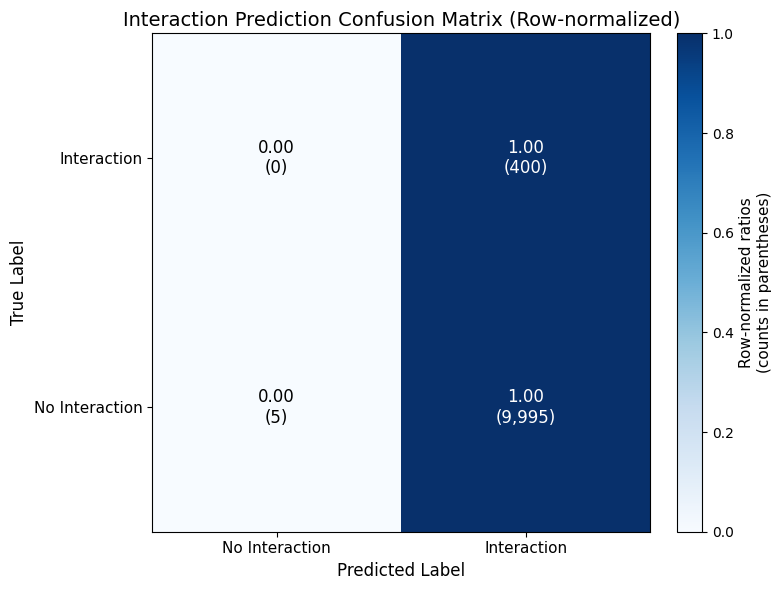


Metrics:
  Accuracy:  0.0389
  Precision: 0.0385
  Recall:    1.0000
  F1 Score:  0.0741


In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# ========== INTERACTION PREDICTION CONFUSION MATRIX ==========
print(f"{'='*80}")
print("INTERACTION PREDICTION CONFUSION MATRIX (Step-level Binary)")
print(f"{'='*80}")

# Convert probabilities to binary predictions
predicted_interaction_binary = (all_predicted_interaction.numpy() > 0.5).astype(int)
target_interaction_binary = all_target_interaction.numpy().astype(int)

# Confusion matrix
cm_interaction = confusion_matrix(target_interaction_binary, predicted_interaction_binary, labels=[0, 1])

# Normalize along rows (true labels)
cm_interaction_ratios = cm_interaction.astype(float)
row_sums = cm_interaction_ratios.sum(axis=1, keepdims=True)
cm_interaction_ratios = np.divide(cm_interaction_ratios, row_sums, where=row_sums != 0)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_interaction_ratios, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

# Add text: ratio + absolute count
for i in range(cm_interaction.shape[0]):
    for j in range(cm_interaction.shape[1]):
        ratio = cm_interaction_ratios[i, j]
        count = cm_interaction[i, j]
        text_color = "white" if ratio > 0.5 else "black"
        ax.text(j, i, f"{ratio:.2f}\n({count:,})",
                ha="center", va="center", color=text_color, fontsize=12)

# Labels
labels = ['No Interaction', 'Interaction']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_ylabel("True Label", fontsize=12)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_title("Interaction Prediction Confusion Matrix (Row-normalized)", fontsize=14)

ax.invert_yaxis()  # Origin at lower left

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Row-normalized ratios\n(counts in parentheses)", fontsize=11)

plt.tight_layout()
plt.show()

# Print metrics
acc = accuracy_score(target_interaction_binary, predicted_interaction_binary)
prec = precision_score(target_interaction_binary, predicted_interaction_binary, zero_division=0)
rec = recall_score(target_interaction_binary, predicted_interaction_binary, zero_division=0)
f1 = f1_score(target_interaction_binary, predicted_interaction_binary, zero_division=0)

print(f"\nMetrics:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")



ZERO-MOMENTUM-CHANGE PREDICTION CONFUSION MATRIX (Particle-level Binary)
Predicts whether all E/p components (ΔKE, ΔPx, ΔPy, ΔPz) are zero


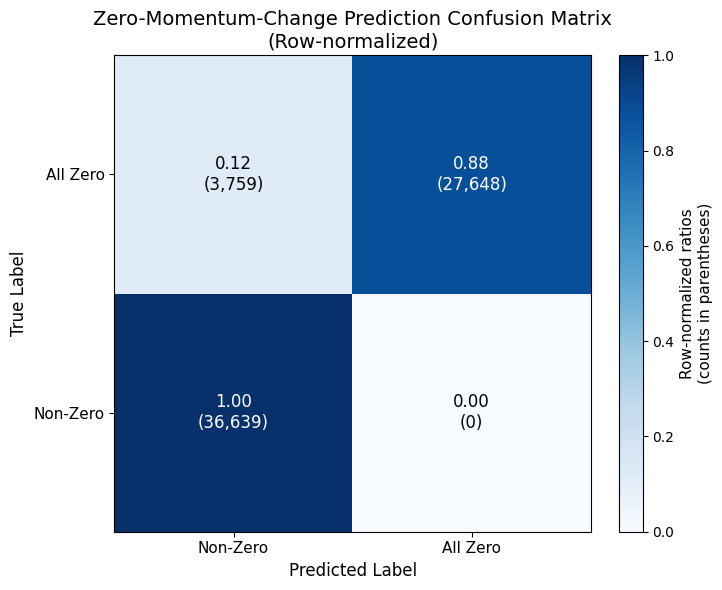


Metrics:
  Accuracy:  0.9448
  Precision: 1.0000
  Recall:    0.8803
  F1 Score:  0.9363
  Total particles: 68,046


In [78]:
# ========== ZERO-MOMENTUM-CHANGE PREDICTION CONFUSION MATRIX ==========
if all_target_em_zero is not None and all_predicted_em_zero is not None:
    print(f"\n{'='*80}")
    print("ZERO-MOMENTUM-CHANGE PREDICTION CONFUSION MATRIX (Particle-level Binary)")
    print(f"{'='*80}")
    print("Predicts whether all E/p components (ΔKE, ΔPx, ΔPy, ΔPz) are zero")
    
    # Configuration: filter by embedded ID(s) if desired
    # Set to None to show all particles, or provide a single ID or list of IDs
    FILTER_BY_IDS = None  # Example: 1153 for proton, or [1153, 1025] for proton and neutron
    
    # Convert to numpy arrays (handle both tensor and numpy cases)
    if isinstance(all_target_em_zero, torch.Tensor):
        target_em_zero_np = all_target_em_zero.cpu().numpy()
    elif isinstance(all_target_em_zero, list):
        # If it's a list, concatenate first (should be list of tensors)
        if len(all_target_em_zero) > 0 and isinstance(all_target_em_zero[0], torch.Tensor):
            target_em_zero_np = torch.cat(all_target_em_zero, dim=0).cpu().numpy()
        else:
            target_em_zero_np = np.array(all_target_em_zero)
    else:
        target_em_zero_np = np.array(all_target_em_zero)
    
    if isinstance(all_predicted_em_zero, torch.Tensor):
        predicted_em_zero_np = all_predicted_em_zero.cpu().numpy()
    elif isinstance(all_predicted_em_zero, list):
        # If it's a list, concatenate first (should be list of tensors)
        if len(all_predicted_em_zero) > 0 and isinstance(all_predicted_em_zero[0], torch.Tensor):
            predicted_em_zero_np = torch.cat(all_predicted_em_zero, dim=0).cpu().numpy()
        else:
            predicted_em_zero_np = np.array(all_predicted_em_zero)
    else:
        predicted_em_zero_np = np.array(all_predicted_em_zero)
    
    # Get particle types if available (for filtering)
    all_particle_types = None
    if all_particle_types_em is not None:
        if isinstance(all_particle_types_em, torch.Tensor):
            all_particle_types = all_particle_types_em.cpu().numpy()
        elif isinstance(all_particle_types_em, list):
            # If it's a list, concatenate first
            if len(all_particle_types_em) > 0 and isinstance(all_particle_types_em[0], torch.Tensor):
                all_particle_types = torch.cat(all_particle_types_em, dim=0).cpu().numpy()
            else:
                all_particle_types = np.array(all_particle_types_em)
        else:
            all_particle_types = np.array(all_particle_types_em)
        
        # Verify alignment
        if len(all_particle_types) != len(target_em_zero_np):
            print(f"⚠ Warning: Particle types length ({len(all_particle_types)}) doesn't match em_zero length ({len(target_em_zero_np)})")
            print("  Proceeding without ID filtering...")
            all_particle_types = None
    
    # Apply ID filter if specified
    if FILTER_BY_IDS is not None and all_particle_types is not None:
        if isinstance(FILTER_BY_IDS, (int, np.integer)):
            filter_ids = [int(FILTER_BY_IDS)]
        else:
            filter_ids = [int(fid) for fid in FILTER_BY_IDS]
        
        filter_mask = np.isin(all_particle_types, filter_ids)
        print(f"  Filter mask: {filter_mask.sum()} particles match IDs {filter_ids} out of {len(filter_mask)} total")
        
        if filter_mask.sum() == 0:
            print(f"⚠ Warning: No particles found with IDs {filter_ids}")
            print("  Available particle type IDs (first 20):", np.unique(all_particle_types)[:20])
            print("  Proceeding without filtering...")
            predicted_em_zero_filtered = predicted_em_zero_np
            target_em_zero_filtered = target_em_zero_np
            filter_str = ""
        else:
            predicted_em_zero_filtered = predicted_em_zero_np[filter_mask]
            target_em_zero_filtered = target_em_zero_np[filter_mask]
            filter_str = f" (filtered: IDs={filter_ids})"
    else:
        predicted_em_zero_filtered = predicted_em_zero_np
        target_em_zero_filtered = target_em_zero_np
        if FILTER_BY_IDS is not None:
            filter_str = " (filtering requested but particle types not available)"
        else:
            filter_str = ""
    
    # Ensure they are numpy arrays (not lists) and convert boolean to int
    predicted_em_zero_filtered = np.asarray(predicted_em_zero_filtered)
    target_em_zero_filtered = np.asarray(target_em_zero_filtered)
    
    # Convert boolean to int if needed (True -> 1, False -> 0)
    if predicted_em_zero_filtered.dtype == bool:
        predicted_em_zero_filtered = predicted_em_zero_filtered.astype(int)
    if target_em_zero_filtered.dtype == bool:
        target_em_zero_filtered = target_em_zero_filtered.astype(int)
    
    if len(predicted_em_zero_filtered) == 0:
        print("\n⚠ Error: No particles to analyze. Check that:")
        print("  1. The evaluation metrics cell has been run")
        print("  2. Target features are available")
        print("  3. If filtering by IDs, the IDs exist in the data")
    else:
        # Convert to binary (True = all zero, False = any non-zero)
        # Note: all_target_em_zero and all_predicted_em_zero are already boolean flags
        # where True means "all zero" and False means "non-zero"
        # So we convert True->1 (all zero) and False->0 (non-zero)
        predicted_em_zero_binary = predicted_em_zero_filtered.astype(int)
        target_em_zero_binary = target_em_zero_filtered.astype(int)
        
        # Confusion matrix
        cm_em_zero = confusion_matrix(target_em_zero_binary, predicted_em_zero_binary, labels=[0, 1])
        
        # Normalize along rows
        cm_em_zero_ratios = cm_em_zero.astype(float)
        row_sums = cm_em_zero_ratios.sum(axis=1, keepdims=True)
        cm_em_zero_ratios = np.divide(cm_em_zero_ratios, row_sums, where=row_sums != 0)
        
        # Plot
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(cm_em_zero_ratios, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        
        # Add text: ratio + absolute count
        for i in range(cm_em_zero.shape[0]):
            for j in range(cm_em_zero.shape[1]):
                ratio = cm_em_zero_ratios[i, j]
                count = cm_em_zero[i, j]
                text_color = "white" if ratio > 0.5 else "black"
                ax.text(j, i, f"{ratio:.2f}\n({count:,})",
                        ha="center", va="center", color=text_color, fontsize=12)
        
        # Labels
        labels = ['Non-Zero', 'All Zero']
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(labels, fontsize=11)
        ax.set_yticklabels(labels, fontsize=11)
        ax.set_ylabel("True Label", fontsize=12)
        ax.set_xlabel("Predicted Label", fontsize=12)
        ax.set_title(f"Zero-Momentum-Change Prediction Confusion Matrix{filter_str}\n(Row-normalized)", fontsize=14)
        
        ax.invert_yaxis()  # Origin at lower left
        
        # Add colorbar
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Row-normalized ratios\n(counts in parentheses)", fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        # Print metrics
        acc_em = accuracy_score(target_em_zero_binary, predicted_em_zero_binary)
        prec_em = precision_score(target_em_zero_binary, predicted_em_zero_binary, zero_division=0)
        rec_em = recall_score(target_em_zero_binary, predicted_em_zero_binary, zero_division=0)
        f1_em = f1_score(target_em_zero_binary, predicted_em_zero_binary, zero_division=0)
        
        print(f"\nMetrics{filter_str}:")
        print(f"  Accuracy:  {acc_em:.4f}")
        print(f"  Precision: {prec_em:.4f}")
        print(f"  Recall:    {rec_em:.4f}")
        print(f"  F1 Score:  {f1_em:.4f}")
        print(f"  Total particles: {len(target_em_zero_binary):,}")
else:
    print("\nZero-momentum-change prediction not available (target features not provided)")
    print("Make sure to run the evaluation metrics cell first!")

  Filter: 27850 particles match IDs [1153] out of 68046 total
FEATURE DISTRIBUTIONS: Target vs Predicted Deltas (filtered: IDs=[1153])


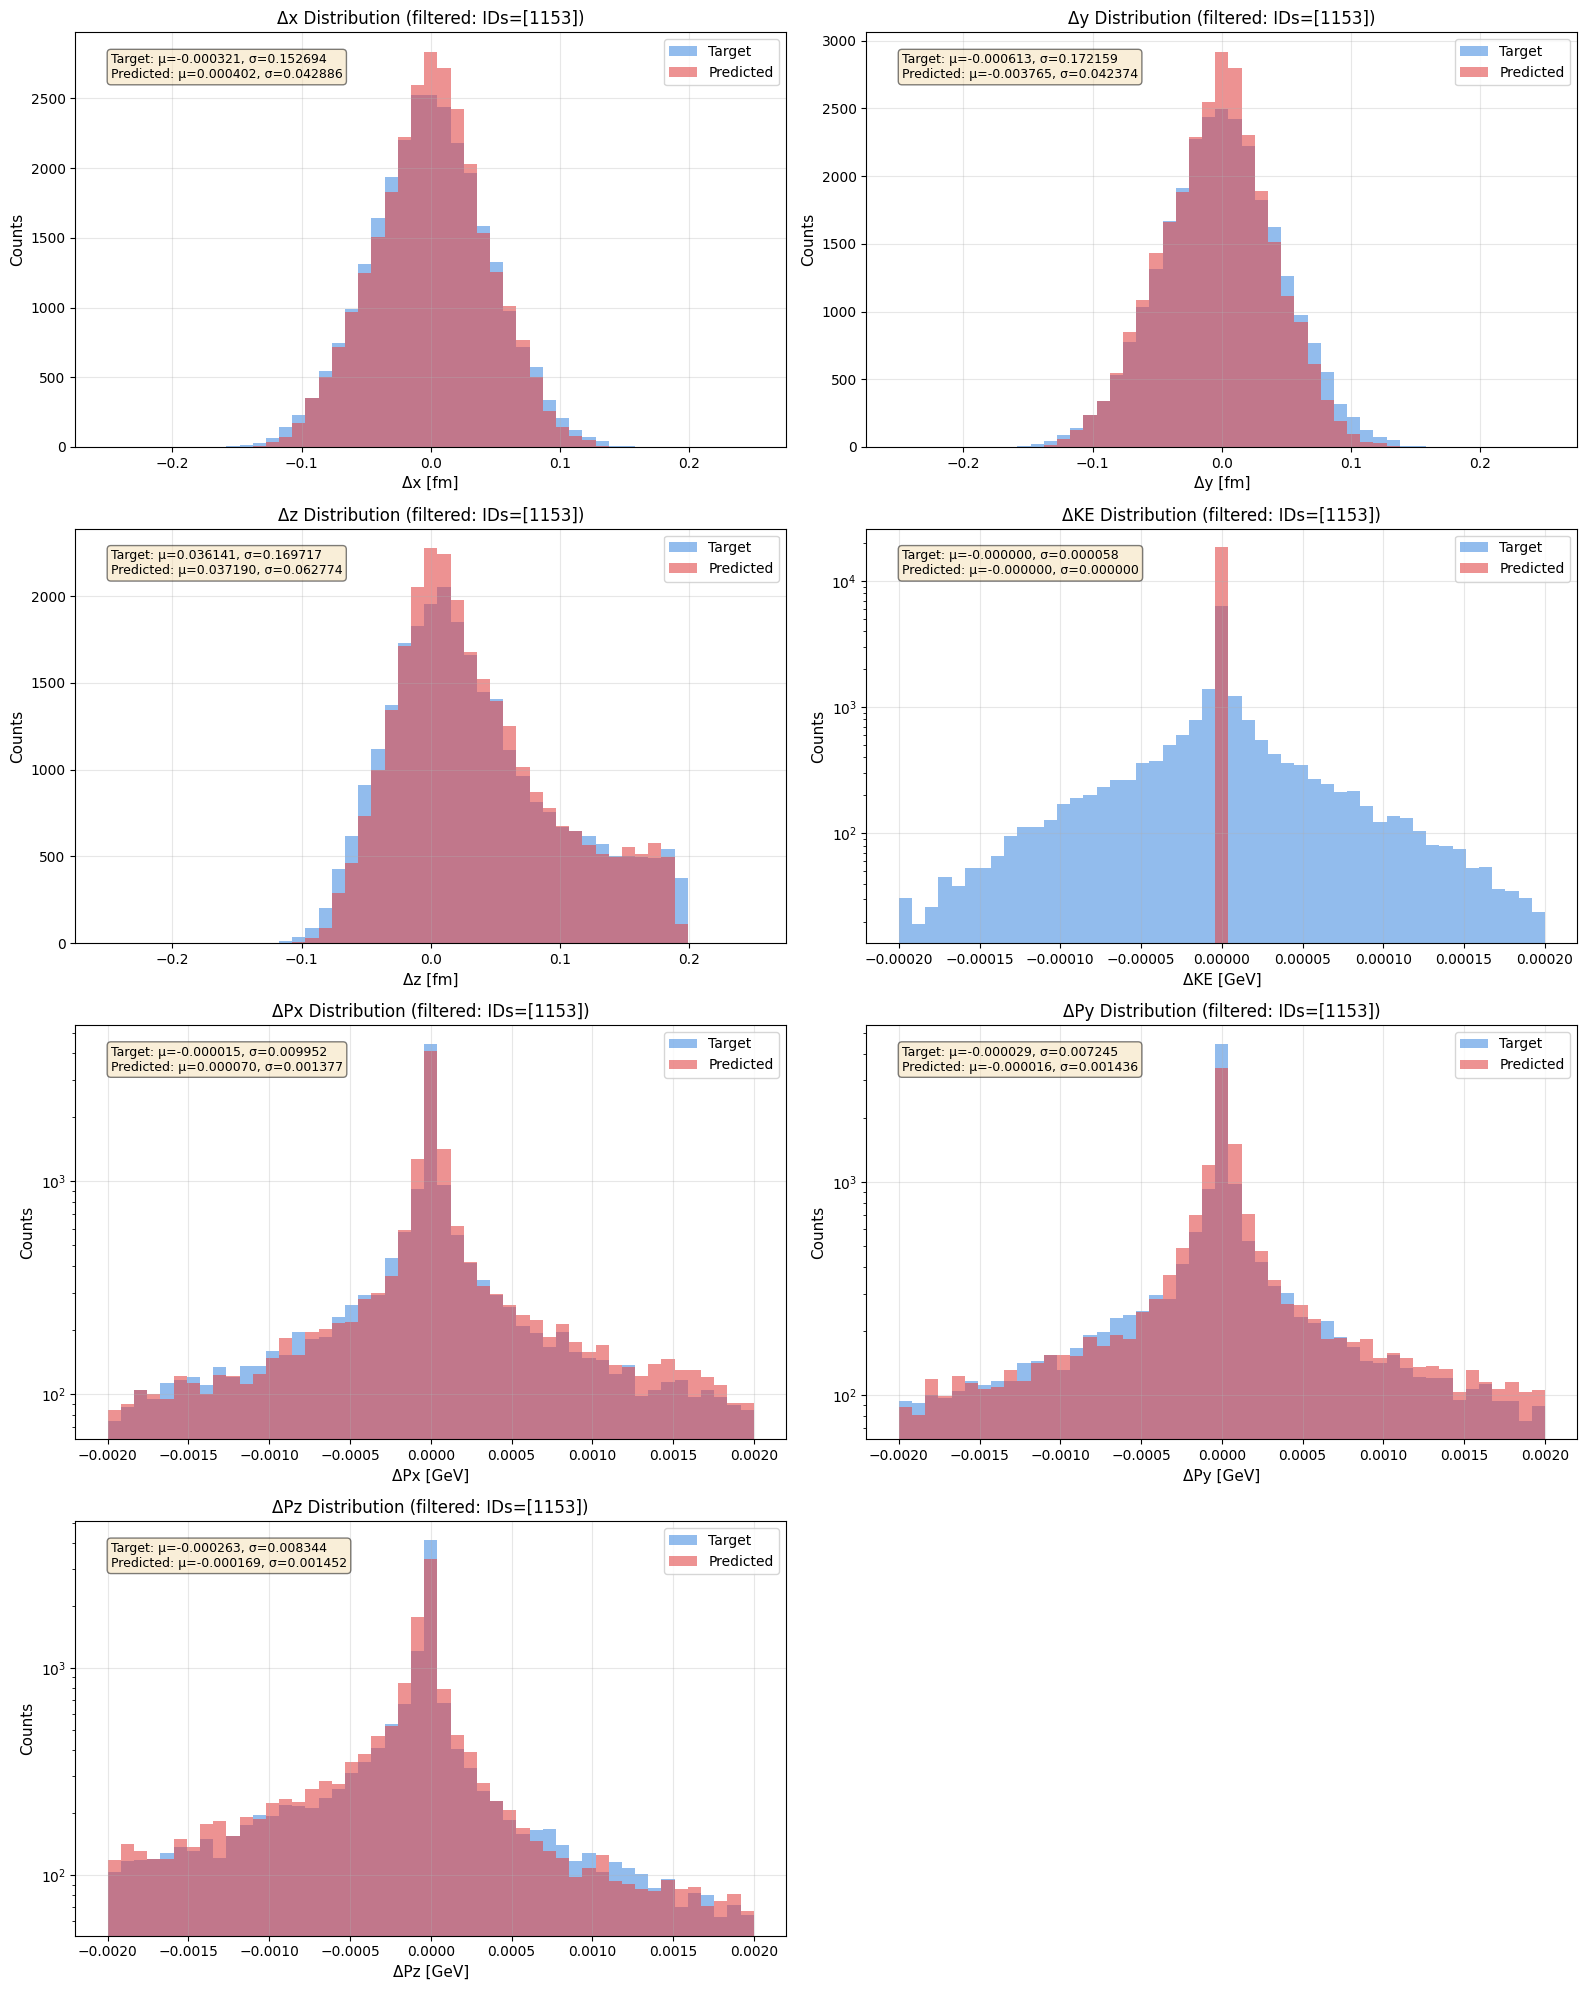


FEATURE STATISTICS
Feature  Target Mean     Target Std      Pred Mean       Pred Std        N         
--------------------------------------------------------------------------------
Δx       -0.000321       0.152694        0.000402        0.042886        27,850    
Δy       -0.000613       0.172159        -0.003765       0.042374        27,850    
Δz       0.036141        0.169717        0.037190        0.062774        27,850    
ΔKE      -0.000000       0.000047        -0.000000       0.000000        27,850    
ΔPx      -0.000010       0.008110        0.000047        0.001122        27,850    
ΔPy      -0.000020       0.005904        -0.000010       0.001170        27,850    
ΔPz      -0.000174       0.006801        -0.000113       0.001186        27,850    

✓ Feature distributions plotted
  Filtered by: IDs=[1153]


In [81]:
# Configuration: filter by embedded ID(s) if desired
# Set to None to show all particles, or provide a single ID or list of IDs
FILTER_BY_IDS = 1153  # Example: 1153 for proton, or [1153, 1025] for proton and neutron

# Feature names and indices (deltas)
feature_info = [
    (0, 'Δx', 'Δx [fm]'),
    (1, 'Δy', 'Δy [fm]'),
    (2, 'Δz', 'Δz [fm]'),
    (3, 'ΔKE', 'ΔKE [GeV]'),
    (4, 'ΔPx', 'ΔPx [GeV]'),
    (5, 'ΔPy', 'ΔPy [GeV]'),
    (6, 'ΔPz', 'ΔPz [GeV]'),
]

if all_target_deltas is None:
    print("Target deltas not available. Please run the evaluation metrics cell first.")
else:
    # Use particle types from evaluation metrics cell (already aligned with deltas)
    # Convert to numpy if needed
    if 'all_particle_types_em' in globals() and all_particle_types_em is not None:
        if isinstance(all_particle_types_em, torch.Tensor):
            all_particle_types_array = all_particle_types_em.cpu().numpy()
        elif isinstance(all_particle_types_em, list):
            if len(all_particle_types_em) > 0 and isinstance(all_particle_types_em[0], torch.Tensor):
                all_particle_types_array = torch.cat(all_particle_types_em, dim=0).cpu().numpy()
            else:
                all_particle_types_array = np.array(all_particle_types_em)
        else:
            all_particle_types_array = np.array(all_particle_types_em)
        
        # Verify alignment
        if len(all_particle_types_array) != len(all_predicted_deltas):
            print(f"⚠ Warning: Particle types length ({len(all_particle_types_array)}) doesn't match deltas length ({len(all_predicted_deltas)})")
            print("  Collecting particle types from scratch...")
            all_particle_types_array = None
    else:
        all_particle_types_array = None
    
    # If we don't have aligned particle types, collect them (but this should match deltas)
    if all_particle_types_array is None:
        print("Collecting particle types from test set (this may take a moment)...")
        all_particle_types_list = []
        model_loaded.eval()
        with torch.no_grad():
            for batch in test_loader:
                batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
                padding_mask = batch['padding_mask']
                particle_types = batch['particle_types']
                has_target_features = batch.get('has_target_features', None)
                
                for b in range(particle_types.size(0)):
                    batch_valid_mask = ~padding_mask[b]
                    
                    # Only collect particle types for particles with target features (to match deltas)
                    if has_target_features is not None:
                        has_target_mask = has_target_features[b] & batch_valid_mask
                    else:
                        has_target_mask = batch_valid_mask
                    
                    if has_target_mask.sum() > 0:
                        all_particle_types_list.append(particle_types[b][has_target_mask].cpu())
        
        if all_particle_types_list:
            all_particle_types_array = torch.cat(all_particle_types_list, dim=0).numpy()
        else:
            all_particle_types_array = None
    
    # Convert deltas to numpy if they're tensors
    if isinstance(all_predicted_deltas, torch.Tensor):
        predicted_deltas_np = all_predicted_deltas.cpu().numpy()
    else:
        predicted_deltas_np = all_predicted_deltas
    
    if isinstance(all_target_deltas, torch.Tensor):
        target_deltas_np = all_target_deltas.cpu().numpy()
    else:
        target_deltas_np = all_target_deltas
    
    # Convert all_target_em_zero to numpy if needed (for E/P filtering)
    target_em_zero_np = None
    if all_target_em_zero is not None:
        if isinstance(all_target_em_zero, torch.Tensor):
            target_em_zero_np = all_target_em_zero.cpu().numpy()
        else:
            target_em_zero_np = np.array(all_target_em_zero)
    
    # Apply ID filter if specified
    if FILTER_BY_IDS is not None and all_particle_types_array is not None:
        if isinstance(FILTER_BY_IDS, (int, np.integer)):
            filter_ids = [int(FILTER_BY_IDS)]
        else:
            filter_ids = [int(fid) for fid in FILTER_BY_IDS]
        
        filter_mask = np.isin(all_particle_types_array, filter_ids)
        print(f"  Filter: {filter_mask.sum()} particles match IDs {filter_ids} out of {len(filter_mask)} total")
        
        if filter_mask.sum() == 0:
            print(f"⚠ Warning: No particles found with IDs {filter_ids}")
            print("  Available particle type IDs (first 20):", np.unique(all_particle_types_array)[:20])
            print("  Proceeding without filtering...")
            predicted_deltas_filtered = predicted_deltas_np
            target_deltas_filtered = target_deltas_np
            target_em_zero_filtered = target_em_zero_np  # Keep full array
            filter_str = ""
        else:
            predicted_deltas_filtered = predicted_deltas_np[filter_mask]
            target_deltas_filtered = target_deltas_np[filter_mask]
            # Also filter em_zero array to match
            if target_em_zero_np is not None:
                target_em_zero_filtered = target_em_zero_np[filter_mask]
            else:
                target_em_zero_filtered = None
            filter_str = f" (filtered: IDs={filter_ids})"
    else:
        predicted_deltas_filtered = predicted_deltas_np
        target_deltas_filtered = target_deltas_np
        target_em_zero_filtered = target_em_zero_np  # Keep full array
        if FILTER_BY_IDS is not None:
            filter_str = " (filtering requested but particle types not available)"
        else:
            filter_str = " (all particles)"
    
    print(f"{'='*80}")
    print(f"FEATURE DISTRIBUTIONS: Target vs Predicted Deltas{filter_str}")
    print(f"{'='*80}")
    
    # Create subplots: 2 per row, 4 rows total
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    axes = axes.flatten()
    
    for idx, (feat_idx, feat_short, feat_name) in enumerate(feature_info):
        ax = axes[idx]
        
        # For E/P features, filter to only include particles with true non-zero-momentum-change
        if feat_short in ['ΔKE', 'ΔPx', 'ΔPy', 'ΔPz']:
            if target_em_zero_filtered is not None:
                # Filter to only particles with true non-zero momentum change (target_em_zero == False)
                nonzero_mask = ~target_em_zero_filtered  # True for non-zero, False for all-zero
                
                # Apply the filter to the already-filtered deltas (if ID filter was applied)
                pred_feat = predicted_deltas_filtered[nonzero_mask, feat_idx]
                true_feat = target_deltas_filtered[nonzero_mask, feat_idx]
            else:
                pred_feat = predicted_deltas_filtered[:, feat_idx]
                true_feat = target_deltas_filtered[:, feat_idx]
        else:
            # Position features: use all particles
            pred_feat = predicted_deltas_filtered[:, feat_idx]
            true_feat = target_deltas_filtered[:, feat_idx]
        
        # Determine bins based on combined data range (same binning for target and predicted)
        combined_data = np.concatenate([true_feat, pred_feat])
        if len(combined_data) > 0:
            data_min = np.min(combined_data)
            data_max = np.max(combined_data)
            
            # Use appropriate bin range based on feature type
            if feat_short in ['Δx', 'Δy', 'Δz']:
                bin_min = -0.25
                bin_max = 0.25
                n_bins = 50
            elif feat_short == 'ΔKE':
                bin_min = -0.0002
                bin_max = 0.0002
                n_bins = 50
            else:  # ΔPx, ΔPy, ΔPz
                bin_min = -0.002
                bin_max = 0.002
                n_bins = 50
            
            bins = np.linspace(bin_min, bin_max, n_bins)
        else:
            # Fallback if no data
            if feat_short in ['Δx', 'Δy', 'Δz']:
                bins = np.linspace(-0.25, 0.25, 50)
            elif feat_short == 'ΔKE':
                bins = np.linspace(-0.0002, 0.0002, 50)
            else:
                bins = np.linspace(-0.002, 0.002, 50)
        
        # Plot histograms with counts (not density), using same bins, no edge color
        counts_true, bins_true, patches_true = ax.hist(true_feat, bins=bins, alpha=0.6, label='Target', color='#4A90E2', edgecolor='none')  # dim blue
        counts_pred, bins_pred, patches_pred = ax.hist(pred_feat, bins=bins, alpha=0.6, label='Predicted', color='#E24A4A', edgecolor='none')  # dim red
        
        ax.set_xlabel(feat_name, fontsize=11)
        ax.set_ylabel('Counts', fontsize=11)
        ax.set_title(f'{feat_short} Distribution{filter_str}', fontsize=12)
        # Use log scale for E/P features
        if feat_short in ['ΔKE', 'ΔPx', 'ΔPy', 'ΔPz']:
            ax.set_yscale('log')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
        
        # Add statistics text
        if len(true_feat) > 0:
            true_mean = np.mean(true_feat)
            true_std = np.std(true_feat)
            pred_mean = np.mean(pred_feat)
            pred_std = np.std(pred_feat)
            
            stats_text = f'Target: μ={true_mean:.6f}, σ={true_std:.6f}\n'
            stats_text += f'Predicted: μ={pred_mean:.6f}, σ={pred_std:.6f}'
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                    verticalalignment='top', fontsize=9, 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Hide the last subplot (8th position)
    axes[7].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print("FEATURE STATISTICS")
    print(f"{'='*80}")
    print(f"{'Feature':<8} {'Target Mean':<15} {'Target Std':<15} {'Pred Mean':<15} {'Pred Std':<15} {'N':<10}")
    print(f"{'-'*80}")
    
    for feat_idx, feat_short, feat_name in feature_info:
        # For statistics, use all particles (not filtered by non-zero for E/P)
        pred_feat = predicted_deltas_filtered[:, feat_idx]
        true_feat = target_deltas_filtered[:, feat_idx]
        
        if len(true_feat) > 0:
            true_mean = np.mean(true_feat)
            true_std = np.std(true_feat)
            pred_mean = np.mean(pred_feat)
            pred_std = np.std(pred_feat)
            
            print(f"{feat_short:<8} {true_mean:<15.6f} {true_std:<15.6f} {pred_mean:<15.6f} {pred_std:<15.6f} {len(true_feat):<10,}")
    
    print(f"\n{'='*80}")
    print("✓ Feature distributions plotted")
    if FILTER_BY_IDS is not None:
        filter_ids_list = [int(fid) for fid in (FILTER_BY_IDS if isinstance(FILTER_BY_IDS, list) else [FILTER_BY_IDS])]
        print(f"  Filtered by: IDs={filter_ids_list}")
    else:
        print(f"  Showing all particles")

  Filter: 27850 particles match IDs [1153] out of 68046 total
2D FEATURE DISTRIBUTION PLOTS (Predicted vs Target Deltas) (filtered: IDs=[1153])

Note: E/P features show only particles with true non-zero-momentum-change



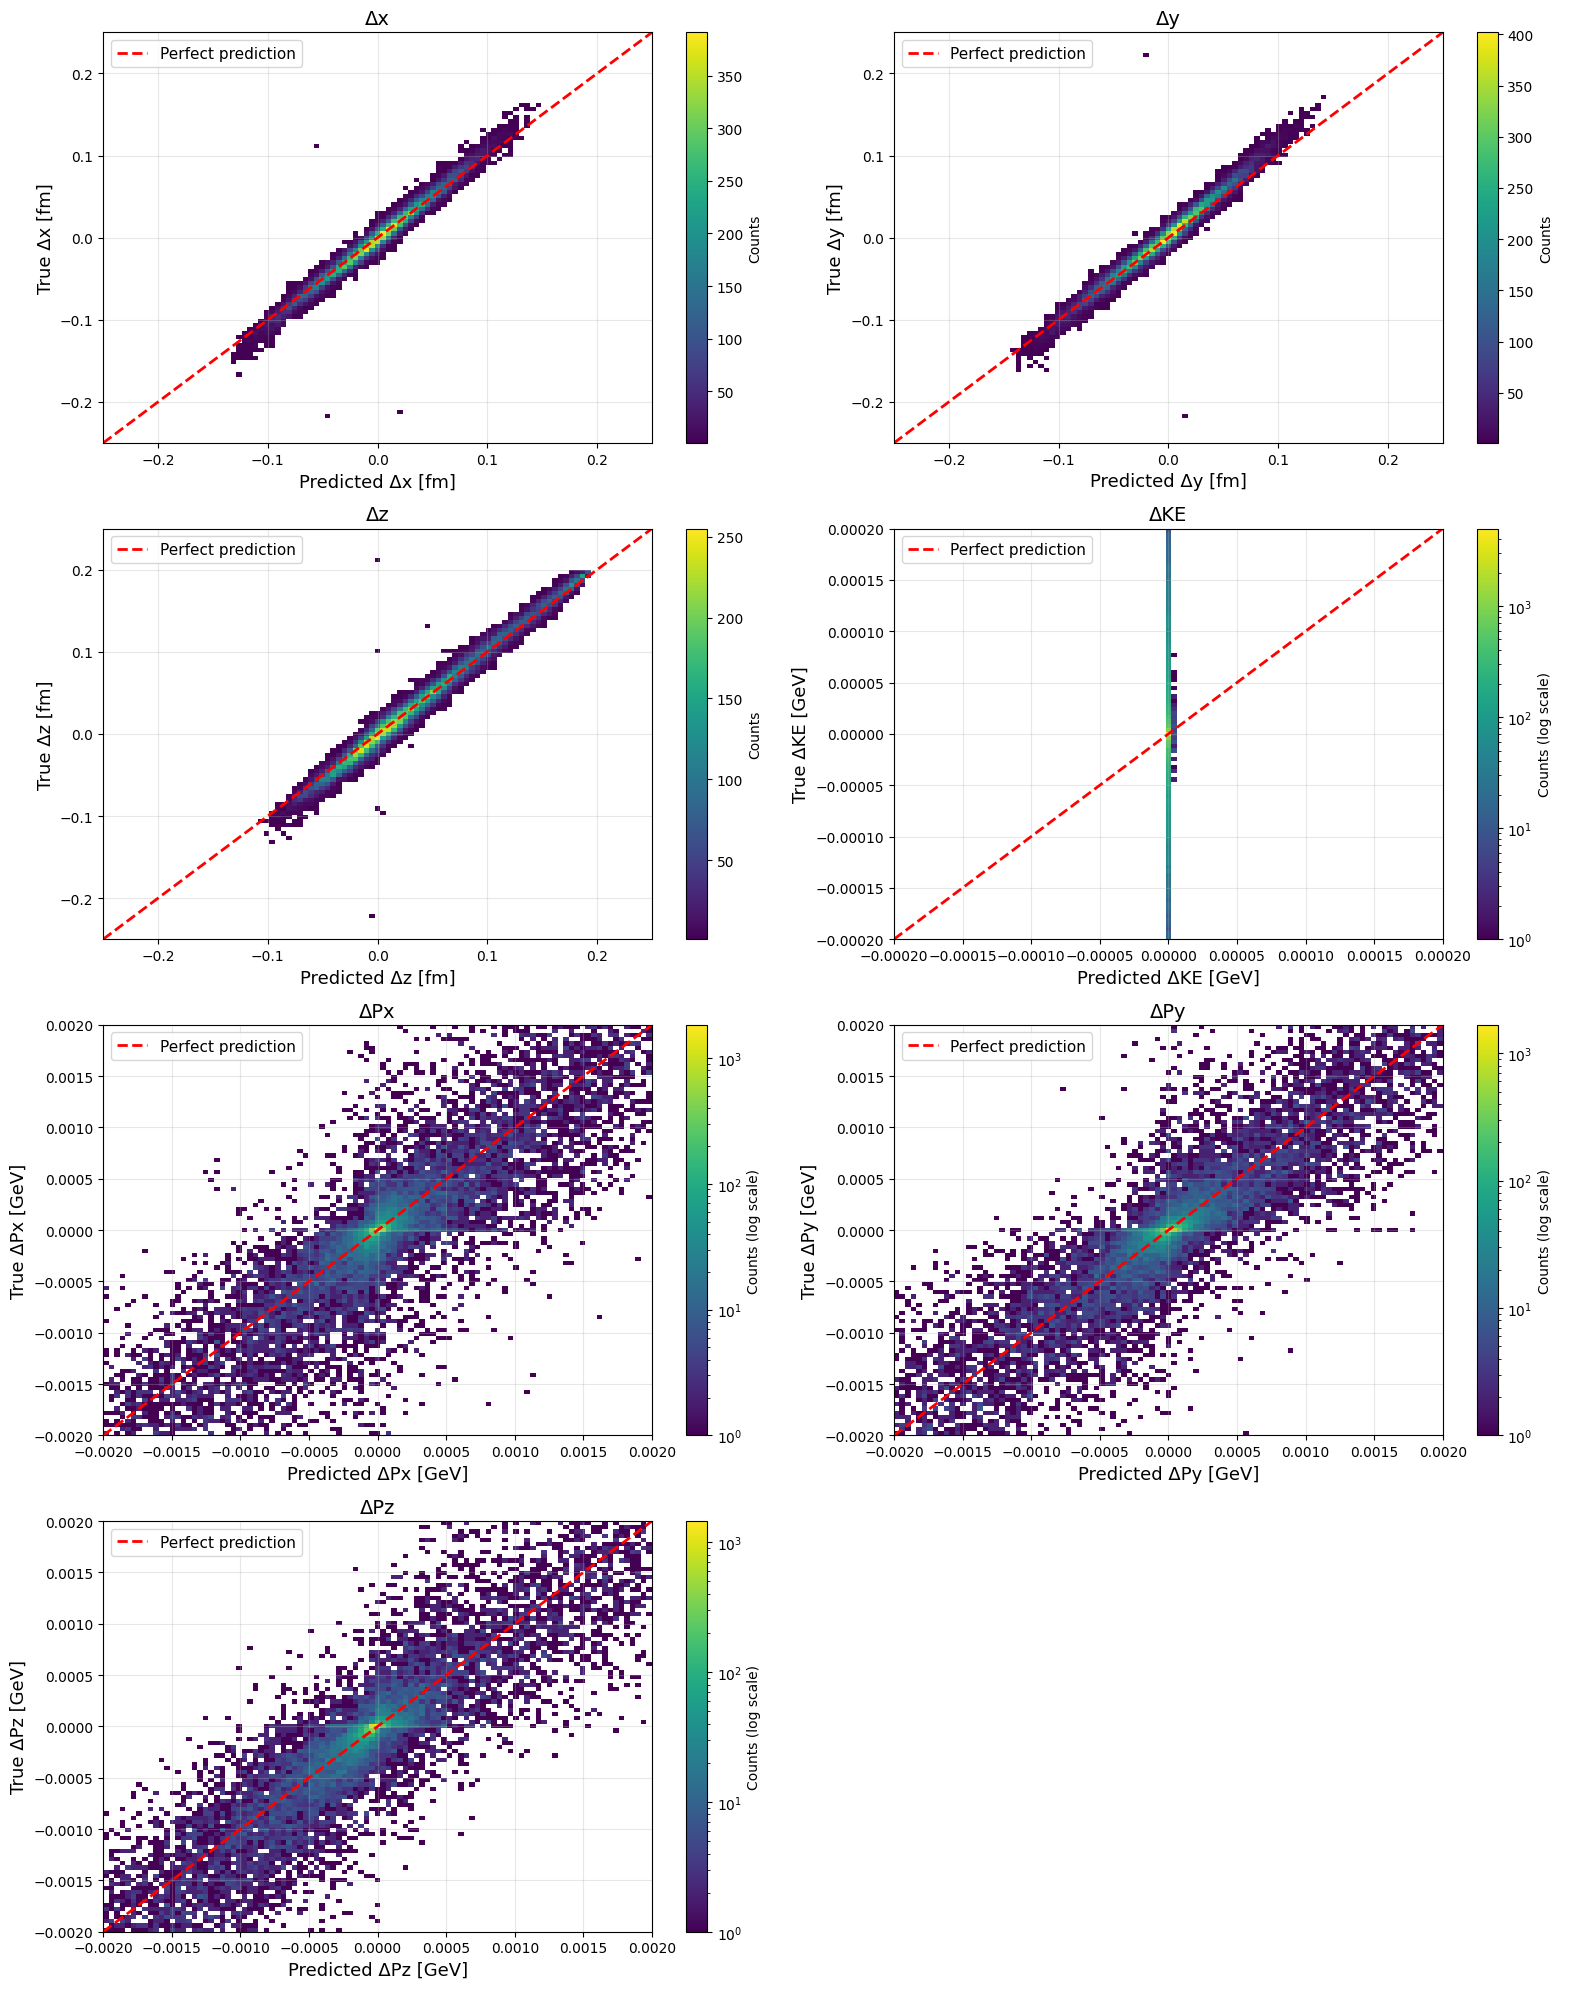


FEATURE STATISTICS
Feature  MAE          RMSE         MedAE        N           
--------------------------------------------------------------------------------
Δx       0.011041     0.145630     0.004808     27,850      
Δy       0.012951     0.166194     0.005441     27,850      
Δz       0.012586     0.156300     0.005865     27,850      
ΔKE      0.000034     0.000058     0.000013     18,496      
ΔPx      0.000783     0.009852     0.000178     18,496      
ΔPy      0.000665     0.007072     0.000167     18,496      
ΔPz      0.000699     0.008218     0.000169     18,496      

✓ All feature distributions plotted
  Filtered by: IDs=[1153]


In [80]:
# ========== 2D FEATURE DISTRIBUTION PLOTS ==========
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch

# Configuration: filter by embedded ID(s) if desired
# Set to None to show all particles, or provide a single ID or list of IDs
FILTER_BY_IDS = 1153  # Example: 1153 for proton, or [1153, 1025] for proton and neutron

def plot_2d_feature_distribution_subplot(
    ax, all_feats_pred, all_feats_target, feature_index, feature_name, 
    bins=None, vmin=None, vmax=None, xlabel="Predicted", ylabel="True", title="2D Feature Distribution",
    use_log_scale=False
):
    """
    Draws a 2D histogram of a feature: predicted vs. true on a given axis.
    
    Parameters:
    -----------
    ax: matplotlib axis to plot on
    all_feats_pred: array, shape [N] - predicted deltas (denormalized)
    all_feats_target: array, shape [N] - target deltas (denormalized)
    feature_index: int, which feature to plot (0=Δx, 1=Δy, 2=Δz, 3=ΔKE, 4=ΔPx, 5=ΔPy, 6=ΔPz)
    feature_name: str, name of the feature for labels
    bins: list, bin edges for the histogram
    vmin, vmax: for color scale
    xlabel, ylabel, title: plot labels
    use_log_scale: bool, whether to use log scale for colorbar
    """
    x = all_feats_pred
    y = all_feats_target
    
    # Set the same range for both axes
    if bins is None:
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        bins = np.linspace(min_val, max_val, 101)
    xmin = bins[0]
    xmax = bins[-1]
    
    # Set up colormap with white for empty bins
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad('white')
    
    if use_log_scale:
        # Compute histogram to get counts
        h_counts, xedges, yedges = np.histogram2d(x, y, bins=bins)
        
        # Use LogNorm for direct log scale (zeros will be white due to set_bad)
        # Set vmin to 1 to avoid log(0), vmax to max count
        vmin_log = 1
        vmax_log = h_counts.max() if h_counts.max() > 0 else 10
        
        # Create meshgrid for pcolormesh
        X, Y = np.meshgrid(xedges, yedges)
        im = ax.pcolormesh(X, Y, h_counts.T, cmap=cmap, shading='flat', 
                          norm=LogNorm(vmin=vmin_log, vmax=vmax_log))
        ax.plot([xmin, xmax], [xmin, xmax], "r--", linewidth=2, label="Perfect prediction")
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_title(title, fontsize=14)
        cbar = plt.colorbar(im, label="Counts (log scale)", ax=ax)
        ax.legend(fontsize=11)
        ax.grid(alpha=0.3)
        h = (h_counts, xedges, yedges, im)  # Return similar structure for compatibility
    else:
        h = ax.hist2d(x, y, bins=bins, cmap=cmap, cmin=1, vmin=vmin, vmax=vmax)
        ax.plot([xmin, xmax], [xmin, xmax], "r--", linewidth=2, label="Perfect prediction")  # reference line
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_title(title, fontsize=14)
        plt.colorbar(h[3], label="Counts", ax=ax)
        ax.legend(fontsize=11)
        ax.grid(alpha=0.3)
    
    # Return statistics
    errors = np.abs(x - y)
    return {
        'mae': errors.mean(),
        'rmse': np.sqrt(np.mean((x - y)**2)),
        'medae': np.median(errors),
        'n_points': len(x)
    }

# Feature names and indices - ordered as: Δx, Δy, Δz, ΔKE, ΔPx, ΔPy, ΔPz
feature_info = [
    (0, 'Δx', 'Δx [fm]', np.linspace(-0.25, 0.25, 100)),
    (1, 'Δy', 'Δy [fm]', np.linspace(-0.25, 0.25, 100)),
    (2, 'Δz', 'Δz [fm]', np.linspace(-0.25, 0.25, 100)),
    (3, 'ΔKE', 'ΔKE [GeV]', np.linspace(-0.0002, 0.0002, 100)),
    (4, 'ΔPx', 'ΔPx [GeV]', np.linspace(-0.002, 0.002, 100)),
    (5, 'ΔPy', 'ΔPy [GeV]', np.linspace(-0.002, 0.002, 100)),
    (6, 'ΔPz', 'ΔPz [GeV]', np.linspace(-0.002, 0.002, 100)),
]

if all_target_deltas is None:
    print("Target deltas not available. Please run the evaluation metrics cell first.")
else:
    # Use particle types from evaluation metrics cell (already aligned with deltas)
    # Convert to numpy if needed
    if 'all_particle_types_em' in globals() and all_particle_types_em is not None:
        if isinstance(all_particle_types_em, torch.Tensor):
            all_particle_types_array = all_particle_types_em.cpu().numpy()
        elif isinstance(all_particle_types_em, list):
            if len(all_particle_types_em) > 0 and isinstance(all_particle_types_em[0], torch.Tensor):
                all_particle_types_array = torch.cat(all_particle_types_em, dim=0).cpu().numpy()
            else:
                all_particle_types_array = np.array(all_particle_types_em)
        else:
            all_particle_types_array = np.array(all_particle_types_em)
        
        # Verify alignment
        if len(all_particle_types_array) != len(all_predicted_deltas):
            print(f"⚠ Warning: Particle types length ({len(all_particle_types_array)}) doesn't match deltas length ({len(all_predicted_deltas)})")
            print("  Proceeding without ID filtering...")
            all_particle_types_array = None
    else:
        all_particle_types_array = None
    
    # Convert deltas to numpy if they're tensors
    if isinstance(all_predicted_deltas, torch.Tensor):
        predicted_deltas_np = all_predicted_deltas.cpu().numpy()
    else:
        predicted_deltas_np = all_predicted_deltas
    
    if isinstance(all_target_deltas, torch.Tensor):
        target_deltas_np = all_target_deltas.cpu().numpy()
    else:
        target_deltas_np = all_target_deltas
    
    # Convert all_target_em_zero to numpy if needed (for E/P filtering)
    target_em_zero_np = None
    if all_target_em_zero is not None:
        if isinstance(all_target_em_zero, torch.Tensor):
            target_em_zero_np = all_target_em_zero.cpu().numpy()
        else:
            target_em_zero_np = np.array(all_target_em_zero)
    
    # Apply ID filter if specified
    if FILTER_BY_IDS is not None and all_particle_types_array is not None:
        if isinstance(FILTER_BY_IDS, (int, np.integer)):
            filter_ids = [int(FILTER_BY_IDS)]
        else:
            filter_ids = [int(fid) for fid in FILTER_BY_IDS]
        
        filter_mask = np.isin(all_particle_types_array, filter_ids)
        print(f"  Filter: {filter_mask.sum()} particles match IDs {filter_ids} out of {len(filter_mask)} total")
        
        if filter_mask.sum() == 0:
            print(f"⚠ Warning: No particles found with IDs {filter_ids}")
            print("  Available particle type IDs (first 20):", np.unique(all_particle_types_array)[:20])
            print("  Proceeding without filtering...")
            predicted_deltas_filtered = predicted_deltas_np
            target_deltas_filtered = target_deltas_np
            target_em_zero_filtered = target_em_zero_np  # Keep full array
            filter_str = ""
        else:
            predicted_deltas_filtered = predicted_deltas_np[filter_mask]
            target_deltas_filtered = target_deltas_np[filter_mask]
            # Also filter em_zero array to match
            if target_em_zero_np is not None:
                target_em_zero_filtered = target_em_zero_np[filter_mask]
            else:
                target_em_zero_filtered = None
            filter_str = f" (filtered: IDs={filter_ids})"
    else:
        predicted_deltas_filtered = predicted_deltas_np
        target_deltas_filtered = target_deltas_np
        target_em_zero_filtered = target_em_zero_np  # Keep full array
        if FILTER_BY_IDS is not None:
            filter_str = " (filtering requested but particle types not available)"
        else:
            filter_str = ""
    
    print(f"{'='*80}")
    print(f"2D FEATURE DISTRIBUTION PLOTS (Predicted vs Target Deltas){filter_str}")
    print(f"{'='*80}")
    print("\nNote: E/P features show only particles with true non-zero-momentum-change\n")
    
    # Create subplots: 2 per row, 4 rows total
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    axes = axes.flatten()
    
    # Plot all features in order
    stats_dict = {}
    for idx, (feat_idx, feat_short, feat_name, default_bins) in enumerate(feature_info):
        # Determine bins based on feature
        if feat_short in ['Δx', 'Δy', 'Δz']:
            bins = np.linspace(-0.25, 0.25, 100)
        elif feat_short == 'ΔKE':
            bins = np.linspace(-0.0002, 0.0002, 100)
        else:  # ΔPx, ΔPy, ΔPz
            bins = np.linspace(-0.002, 0.002, 100)
        
        # For E/P features, filter to only include particles with true non-zero-momentum-change
        if feat_short in ['ΔKE', 'ΔPx', 'ΔPy', 'ΔPz']:
            if target_em_zero_filtered is not None:
                # Filter to only particles with true non-zero momentum change
                nonzero_mask = ~target_em_zero_filtered  # True for non-zero, False for all-zero
                pred_feat = predicted_deltas_filtered[nonzero_mask, feat_idx]
                true_feat = target_deltas_filtered[nonzero_mask, feat_idx]
            else:
                pred_feat = predicted_deltas_filtered[:, feat_idx]
                true_feat = target_deltas_filtered[:, feat_idx]
        else:
            # Position features: use all particles
            pred_feat = predicted_deltas_filtered[:, feat_idx]
            true_feat = target_deltas_filtered[:, feat_idx]
        
        # Use log scale for E/P features
        use_log = feat_short in ['ΔKE', 'ΔPx', 'ΔPy', 'ΔPz']
        
        stats = plot_2d_feature_distribution_subplot(
            axes[idx], pred_feat, true_feat,
            feature_index=feat_idx, 
            feature_name=feat_short,
            bins=bins,
            xlabel=f"Predicted {feat_name}",
            ylabel=f"True {feat_name}",
            title=f"{feat_short}",
            use_log_scale=use_log
        )
        stats_dict[feat_short] = stats
    
    # Hide the last subplot (8th position, since we only have 7 features)
    axes[7].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print("FEATURE STATISTICS")
    print(f"{'='*80}")
    print(f"{'Feature':<8} {'MAE':<12} {'RMSE':<12} {'MedAE':<12} {'N':<12}")
    print(f"{'-'*80}")
    for feat_short in ['Δx', 'Δy', 'Δz', 'ΔKE', 'ΔPx', 'ΔPy', 'ΔPz']:
        stats = stats_dict[feat_short]
        print(f"{feat_short:<8} {stats['mae']:<12.6f} {stats['rmse']:<12.6f} {stats['medae']:<12.6f} {stats['n_points']:<12,}")
    
    print(f"\n{'='*80}")
    print("✓ All feature distributions plotted")
    if FILTER_BY_IDS is not None:
        filter_ids_list = [int(fid) for fid in (FILTER_BY_IDS if isinstance(FILTER_BY_IDS, list) else [FILTER_BY_IDS])]
        print(f"  Filtered by: IDs={filter_ids_list}")
    else:
        print(f"  Showing all particles")